In [1]:
import pandas as pd
import numpy as np
import optuna
import shap
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

def prepare_features(train_df, test_df, feature_cols, target_col):
    X_train = train_df[feature_cols].copy()
    y_train = train_df[target_col].copy()
    X_test = test_df[feature_cols].copy()
    y_test = test_df[target_col].copy()

    imputer = SimpleImputer(strategy='median')
    X_train_imp = imputer.fit_transform(X_train)
    X_test_imp = imputer.transform(X_test)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_imp)
    X_test_scaled = scaler.transform(X_test_imp)

    return X_train_scaled, X_test_scaled, y_train, y_test, imputer, scaler

def evaluate_model(y_true, y_pred, name=""):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    underestimations = (y_pred < y_true).sum()
    svr = underestimations / len(y_true) * 100
    overestimations = (y_pred > y_true).sum()
    ovr = overestimations / len(y_true) * 100
    print(f"\n{'='*50}")
    print(f"{name}")
    print(f"{'='*50}")
    print(f"MAE:  {mae:.6f}")
    print(f"RMSE: {rmse:.6f}")
    print(f"R2:   {r2:.6f}")
    print(f"SVR (недооценка): {svr:.2f}% ({underestimations}/{len(y_true)})")
    print(f"OVR (переоценка): {ovr:.2f}% ({overestimations}/{len(y_true)})")
    return {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'SVR': svr, 'OVR': ovr}

def explain_with_shap(model, X_sample, feature_names):
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_sample)
    plt.figure(figsize=(12, 5))
    shap.summary_plot(shap_values, X_sample, feature_names=feature_names, show=False)
    plt.tight_layout()
    plt.show()
    importance_df = pd.DataFrame({'feature': feature_names, 'shap_importance': np.abs(shap_values).mean(axis=0)}).sort_values('shap_importance', ascending=False)
    return importance_df, shap_values

def objective_random_forest(trial, X_train, y_train, X_val, y_val):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500, step=50),
        'max_depth': trial.suggest_int('max_depth', 5, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'random_state': 42,
        'n_jobs': -1
    }
    model = RandomForestRegressor(**params)
    model.fit(X_train, y_train)
    pred = model.predict(X_val)
    return mean_absolute_error(y_val, pred)

def tune_random_forest(X_train, y_train, X_val, y_val, n_trials=20):
    study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(lambda trial: objective_random_forest(trial, X_train, y_train, X_val, y_val), n_trials=n_trials, show_progress_bar=True)
    return study.best_params, study.best_value

/home/user/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


=== ЗАДАЧА 1: ПРОГНОЗ НА 5 МИНУТ (target_5min) ===

Linear Regression (базовая модель):

Linear Regression (5min)
MAE:  1.755146
RMSE: 4.132716
R2:   0.897323
SVR (недооценка): 42.08% (83574/198611)
OVR (переоценка): 57.92% (115037/198611)

Random Forest без тюнинга (базовые параметры):


[I 2026-05-27 09:50:11,119] A new study created in memory with name: no-name-6ea7e78a-2e42-4e19-8264-687a8a439cac



Random Forest (5min) - default
MAE:  1.285390
RMSE: 3.645749
R2:   0.920095
SVR (недооценка): 31.33% (62230/198611)
OVR (переоценка): 68.67% (136381/198611)

=== Optuna тюнинг для Random Forest ===



Best trial: 0. Best value: 1.26653:   5%|▌         | 1/20 [01:09<21:54, 69.17s/it]

[I 2026-05-27 09:51:20,293] Trial 0 finished with value: 1.2665284719569863 and parameters: {'n_estimators': 250, 'max_depth': 20, 'min_samples_split': 15, 'min_samples_leaf': 6, 'max_features': 'sqrt'}. Best is trial 0 with value: 1.2665284719569863.


...

[I 2026-05-27 10:29:32,566] Trial 17 finished with value: 1.2412455661885446 and parameters: {'n_estimators': 150, 'max_depth': 20, 'min_samples_split': 17, 'min_samples_leaf': 9, 'max_features': None}. Best is trial 7 with value: 1.2408472719282635.


Best trial: 7. Best value: 1.24085:  95%|█████████▌| 19/20 [41:22<02:32, 152.93s/it]

[I 2026-05-27 10:31:33,621] Trial 18 finished with value: 1.3083639565894276 and parameters: {'n_estimators': 500, 'max_depth': 15, 'min_samples_split': 17, 'min_samples_leaf': 10, 'max_features': 'sqrt'}. Best is trial 7 with value: 1.2408472719282635.


Best trial: 7. Best value: 1.24085: 100%|██████████| 20/20 [41:54<00:00, 125.72s/it]


[I 2026-05-27 10:32:05,554] Trial 19 finished with value: 1.3582311748096227 and parameters: {'n_estimators': 150, 'max_depth': 12, 'min_samples_split': 17, 'min_samples_leaf': 9, 'max_features': 'log2'}. Best is trial 7 with value: 1.2408472719282635.
Best params: {'n_estimators': 150, 'max_depth': 20, 'min_samples_split': 16, 'min_samples_leaf': 10, 'max_features': None}
Best val MAE: 1.2408

Random Forest (5min) - tuned
MAE:  1.238630
RMSE: 3.606550
R2:   0.921804
SVR (недооценка): 30.87% (61317/198611)
OVR (переоценка): 69.13% (137294/198611)

SHAP Analysis:


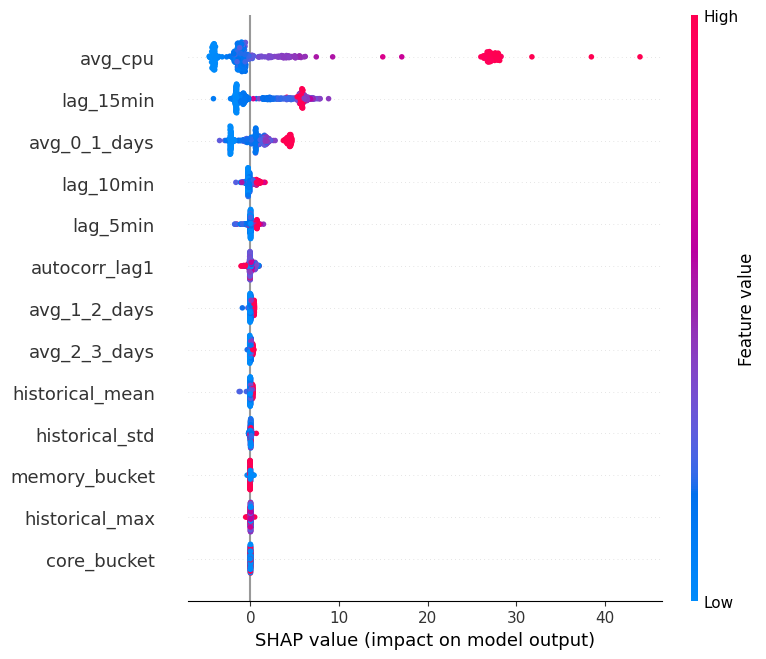

Top 10 features:
            feature  shap_importance
0           avg_cpu         7.231326
5         lag_15min         3.255502
9      avg_0_1_days         1.846806
4         lag_10min         0.356524
3          lag_5min         0.280151
12    autocorr_lag1         0.206018
10     avg_1_2_days         0.129353
11     avg_2_3_days         0.105028
6   historical_mean         0.091798
7    historical_std         0.052055


In [2]:
print("=== ЗАДАЧА 1: ПРОГНОЗ НА 5 МИНУТ (target_5min) ===\n")

train_df = pd.read_parquet('train_df.parquet')
test_df = pd.read_parquet('test_df.parquet')

train_df = train_df[(train_df['core_bucket'] != '>24') & (train_df['memory_bucket'] != '>64')]
test_df = test_df[(test_df['core_bucket'] != '>24') & (test_df['memory_bucket'] != '>64')]

train_df['core_bucket'] = pd.to_numeric(train_df['core_bucket'])
train_df['memory_bucket'] = pd.to_numeric(train_df['memory_bucket'])
test_df['core_bucket'] = pd.to_numeric(test_df['core_bucket'])
test_df['memory_bucket'] = pd.to_numeric(test_df['memory_bucket'])

feature_cols = ['avg_cpu', 'core_bucket', 'memory_bucket', 'lag_5min', 'lag_10min', 'lag_15min',
                'historical_mean', 'historical_std', 'historical_max', 'avg_0_1_days',
                'avg_1_2_days', 'avg_2_3_days', 'autocorr_lag1']

target_col = 'target_5min'

X_train, X_test, y_train, y_test, imputer, scaler = prepare_features(train_df, test_df, feature_cols, target_col)

X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

print("Linear Regression (базовая модель):")
lr = LinearRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)
evaluate_model(y_test, pred_lr, "Linear Regression (5min)")

print("\nRandom Forest без тюнинга (базовые параметры):")
rf_default = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
rf_default.fit(X_train, y_train)
pred_default = rf_default.predict(X_test)
evaluate_model(y_test, pred_default, "Random Forest (5min) - default")

print("\n=== Optuna тюнинг для Random Forest ===\n")
best_params, best_value = tune_random_forest(X_tr, y_tr, X_val, y_val, n_trials=20)
print(f"Best params: {best_params}")
print(f"Best val MAE: {best_value:.4f}")

rf_best = RandomForestRegressor(**best_params, random_state=42, n_jobs=-1)
rf_best.fit(X_train, y_train)
pred_best = rf_best.predict(X_test)
evaluate_model(y_test, pred_best, "Random Forest (5min) - tuned")

print("\nSHAP Analysis:")
importance_df, _ = explain_with_shap(rf_best, X_test[:500], feature_cols)
print("Top 10 features:")
print(importance_df.head(10))

=== ЗАДАЧА 2: ПРОГНОЗ МАКСИМУМА ЗА 24 ЧАСА (target_24h) ===

Linear Regression (базовая модель):


[I 2026-05-27 10:40:03,944] A new study created in memory with name: no-name-40ab04be-2643-4b8f-9024-d7c7af947ebe



Linear Regression (24h)
MAE:  2.673625
RMSE: 6.944191
R2:   0.711011
SVR (недооценка): 30.29% (60155/198611)
OVR (переоценка): 69.71% (138456/198611)

=== Optuna тюнинг для Random Forest ===



Best trial: 0. Best value: 2.2886:   5%|▌         | 1/20 [01:09<22:05, 69.74s/it]

[I 2026-05-27 10:41:13,690] Trial 0 finished with value: 2.288601822700225 and parameters: {'n_estimators': 250, 'max_depth': 20, 'min_samples_split': 15, 'min_samples_leaf': 6, 'max_features': 'sqrt'}. Best is trial 0 with value: 2.288601822700225.


...

[I 2026-05-27 11:14:10,707] Trial 17 finished with value: 2.3578043102469795 and parameters: {'n_estimators': 350, 'max_depth': 12, 'min_samples_split': 10, 'min_samples_leaf': 5, 'max_features': None}. Best is trial 6 with value: 2.2879733121211334.


Best trial: 6. Best value: 2.28797:  95%|█████████▌| 19/20 [35:02<01:55, 115.49s/it]

[I 2026-05-27 11:15:06,114] Trial 18 finished with value: 2.2995188815819367 and parameters: {'n_estimators': 200, 'max_depth': 20, 'min_samples_split': 18, 'min_samples_leaf': 10, 'max_features': 'sqrt'}. Best is trial 6 with value: 2.2879733121211334.


Best trial: 6. Best value: 2.28797: 100%|██████████| 20/20 [35:30<00:00, 106.50s/it]


[I 2026-05-27 11:15:33,980] Trial 19 finished with value: 2.303933258095681 and parameters: {'n_estimators': 100, 'max_depth': 18, 'min_samples_split': 4, 'min_samples_leaf': 7, 'max_features': 'log2'}. Best is trial 6 with value: 2.2879733121211334.
Best params: {'n_estimators': 100, 'max_depth': 19, 'min_samples_split': 6, 'min_samples_leaf': 7, 'max_features': None}
Best val MAE: 2.2880

Random Forest (24h) - tuned
MAE:  2.364976
RMSE: 6.663802
R2:   0.733877
SVR (недооценка): 32.88% (65312/198611)
OVR (переоценка): 67.12% (133299/198611)

SHAP Analysis:


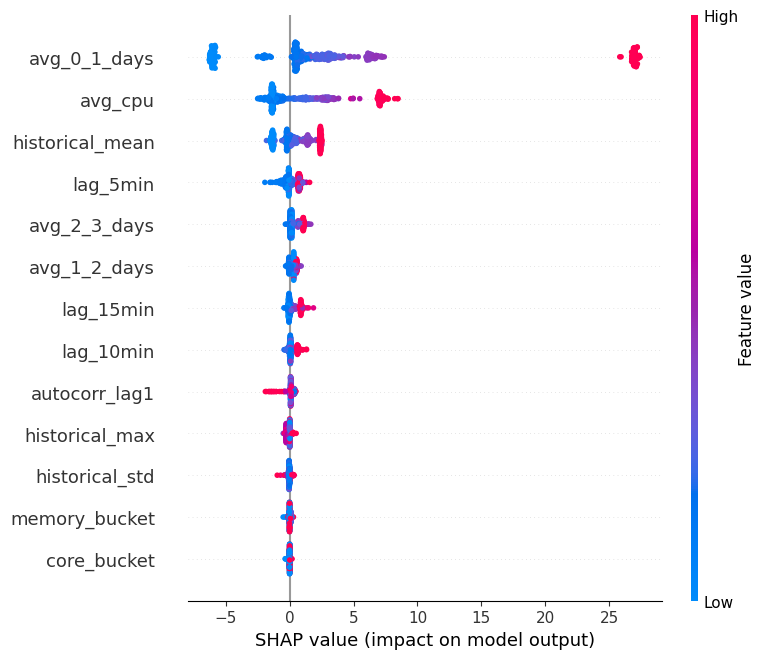

Top 10 features:
            feature  shap_importance
9      avg_0_1_days         7.652826
0           avg_cpu         2.638657
6   historical_mean         1.054261
3          lag_5min         0.418755
11     avg_2_3_days         0.418667
10     avg_1_2_days         0.284335
5         lag_15min         0.283723
4         lag_10min         0.202135
12    autocorr_lag1         0.196294
8    historical_max         0.101530


In [3]:
print("=== ЗАДАЧА 2: ПРОГНОЗ МАКСИМУМА ЗА 24 ЧАСА (target_24h) ===\n")

train_df = pd.read_parquet('train_df.parquet')
test_df = pd.read_parquet('test_df.parquet')

train_df = train_df[(train_df['core_bucket'] != '>24') & (train_df['memory_bucket'] != '>64')]
test_df = test_df[(test_df['core_bucket'] != '>24') & (test_df['memory_bucket'] != '>64')]

train_df['core_bucket'] = pd.to_numeric(train_df['core_bucket'])
train_df['memory_bucket'] = pd.to_numeric(train_df['memory_bucket'])
test_df['core_bucket'] = pd.to_numeric(test_df['core_bucket'])
test_df['memory_bucket'] = pd.to_numeric(test_df['memory_bucket'])

feature_cols = ['avg_cpu', 'core_bucket', 'memory_bucket', 'lag_5min', 'lag_10min', 'lag_15min',
                'historical_mean', 'historical_std', 'historical_max', 'avg_0_1_days',
                'avg_1_2_days', 'avg_2_3_days', 'autocorr_lag1']

target_col = 'target_24h'

X_train, X_test, y_train, y_test, imputer, scaler = prepare_features(train_df, test_df, feature_cols, target_col)

X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

print("Linear Regression (базовая модель):")
lr = LinearRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)
evaluate_model(y_test, pred_lr, "Linear Regression (24h)")

print("\n=== Optuna тюнинг для Random Forest ===\n")
best_params, best_value = tune_random_forest(X_tr, y_tr, X_val, y_val, n_trials=20)
print(f"Best params: {best_params}")
print(f"Best val MAE: {best_value:.4f}")

rf_best = RandomForestRegressor(**best_params, random_state=42, n_jobs=-1)
rf_best.fit(X_train, y_train)
pred_best = rf_best.predict(X_test)
evaluate_model(y_test, pred_best, "Random Forest (24h) - tuned")

print("\nSHAP Analysis:")
importance_df, _ = explain_with_shap(rf_best, X_test[:500], feature_cols)
print("Top 10 features:")
print(importance_df.head(10))

=== ЗАДАЧА 3: ПРОГНОЗ НА ВЕСЬ СРОК ЖИЗНИ (target_lifetime_mean) ===

Ridge Regression (базовая модель):

Ridge (lifetime)
MAE:  1.500888
RMSE: 3.867930
R2:   0.869517
SVR (недооценка): 36.52% (72529/198611)
OVR (переоценка): 63.48% (126082/198611)

Random Forest без тюнинга (базовые параметры):


[I 2026-05-27 11:24:27,432] A new study created in memory with name: no-name-97434610-c8ef-4103-93f3-4f8c391183b7



Random Forest (lifetime) - default
MAE:  1.208285
RMSE: 3.703600
R2:   0.880369
SVR (недооценка): 37.14% (73762/198611)
OVR (переоценка): 62.86% (124849/198611)

=== Optuna тюнинг для Random Forest ===



Best trial: 0. Best value: 0.845358:   5%|▌         | 1/20 [01:09<22:06, 69.82s/it]

[I 2026-05-27 11:25:37,247] Trial 0 finished with value: 0.8453579526916183 and parameters: {'n_estimators': 250, 'max_depth': 20, 'min_samples_split': 15, 'min_samples_leaf': 6, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.8453579526916183.


...

[I 2026-05-27 12:05:19,717] Trial 17 finished with value: 0.7075164970570088 and parameters: {'n_estimators': 200, 'max_depth': 20, 'min_samples_split': 17, 'min_samples_leaf': 9, 'max_features': None}. Best is trial 6 with value: 0.7074564044379127.


Best trial: 6. Best value: 0.707456:  95%|█████████▌| 19/20 [41:50<02:32, 152.08s/it]

[I 2026-05-27 12:06:18,317] Trial 18 finished with value: 0.9502531035049598 and parameters: {'n_estimators': 250, 'max_depth': 15, 'min_samples_split': 4, 'min_samples_leaf': 7, 'max_features': 'sqrt'}. Best is trial 6 with value: 0.7074564044379127.


Best trial: 6. Best value: 0.707456: 100%|██████████| 20/20 [42:32<00:00, 127.63s/it]


[I 2026-05-27 12:07:00,044] Trial 19 finished with value: 1.063470212489717 and parameters: {'n_estimators': 200, 'max_depth': 12, 'min_samples_split': 13, 'min_samples_leaf': 9, 'max_features': 'log2'}. Best is trial 6 with value: 0.7074564044379127.
Best params: {'n_estimators': 100, 'max_depth': 19, 'min_samples_split': 6, 'min_samples_leaf': 7, 'max_features': None}
Best val MAE: 0.7075

Random Forest (lifetime) - tuned
MAE:  1.206515
RMSE: 3.713032
R2:   0.879758
SVR (недооценка): 38.05% (75565/198611)
OVR (переоценка): 61.95% (123046/198611)

Ensemble (Random Forest tuned + Ridge):

Ensemble (lifetime)
MAE:  1.284307
RMSE: 3.580674
R2:   0.888178
SVR (недооценка): 34.33% (68184/198611)
OVR (переоценка): 65.67% (130427/198611)

SHAP Analysis:


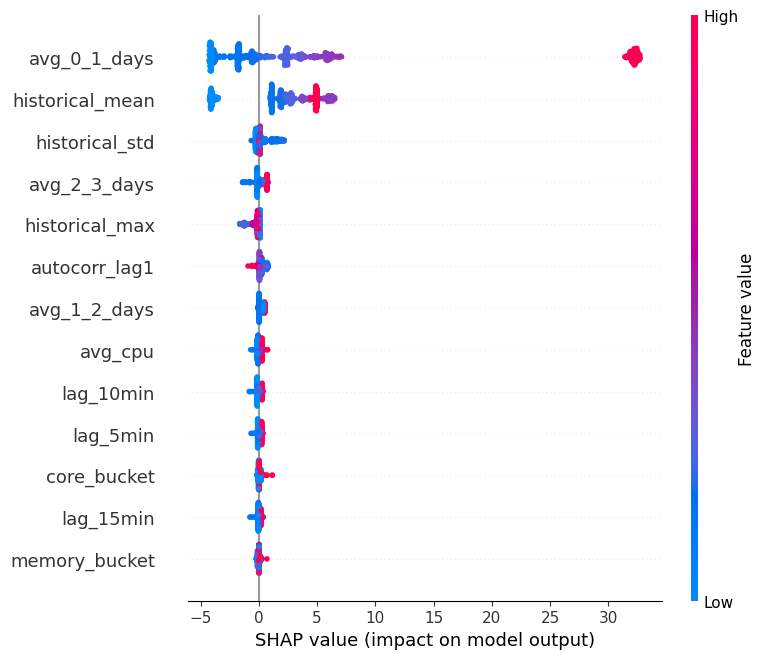

Top 10 features:
            feature  shap_importance
9      avg_0_1_days         8.414939
6   historical_mean         3.429868
7    historical_std         0.425069
11     avg_2_3_days         0.304276
8    historical_max         0.254831
12    autocorr_lag1         0.235233
10     avg_1_2_days         0.231665
0           avg_cpu         0.139261
4         lag_10min         0.134820
3          lag_5min         0.109215


In [4]:
print("=== ЗАДАЧА 3: ПРОГНОЗ НА ВЕСЬ СРОК ЖИЗНИ (target_lifetime_mean) ===\n")

train_df = pd.read_parquet('train_df.parquet')
test_df = pd.read_parquet('test_df.parquet')

train_df = train_df[(train_df['core_bucket'] != '>24') & (train_df['memory_bucket'] != '>64')]
test_df = test_df[(test_df['core_bucket'] != '>24') & (test_df['memory_bucket'] != '>64')]

train_df['core_bucket'] = pd.to_numeric(train_df['core_bucket'])
train_df['memory_bucket'] = pd.to_numeric(train_df['memory_bucket'])
test_df['core_bucket'] = pd.to_numeric(test_df['core_bucket'])
test_df['memory_bucket'] = pd.to_numeric(test_df['memory_bucket'])

feature_cols = ['avg_cpu', 'core_bucket', 'memory_bucket', 'lag_5min', 'lag_10min', 'lag_15min',
                'historical_mean', 'historical_std', 'historical_max', 'avg_0_1_days',
                'avg_1_2_days', 'avg_2_3_days', 'autocorr_lag1']

target_col = 'target_lifetime_mean'

X_train, X_test, y_train, y_test, imputer, scaler = prepare_features(train_df, test_df, feature_cols, target_col)

X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

print("Ridge Regression (базовая модель):")
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
pred_ridge = ridge.predict(X_test)
evaluate_model(y_test, pred_ridge, "Ridge (lifetime)")

print("\nRandom Forest без тюнинга (базовые параметры):")
rf_default = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
rf_default.fit(X_train, y_train)
pred_default = rf_default.predict(X_test)
evaluate_model(y_test, pred_default, "Random Forest (lifetime) - default")

print("\n=== Optuna тюнинг для Random Forest ===\n")
best_params, best_value = tune_random_forest(X_tr, y_tr, X_val, y_val, n_trials=20)
print(f"Best params: {best_params}")
print(f"Best val MAE: {best_value:.4f}")

rf_best = RandomForestRegressor(**best_params, random_state=42, n_jobs=-1)
rf_best.fit(X_train, y_train)
pred_rf_best = rf_best.predict(X_test)
evaluate_model(y_test, pred_rf_best, "Random Forest (lifetime) - tuned")

print("\nEnsemble (Random Forest tuned + Ridge):")
pred_ensemble = (pred_rf_best + pred_ridge) / 2
evaluate_model(y_test, pred_ensemble, "Ensemble (lifetime)")

print("\nSHAP Analysis:")
importance_df, _ = explain_with_shap(rf_best, X_test[:500], feature_cols)
print("Top 10 features:")
print(importance_df.head(10))

In [5]:
!pip install catboost --break-system-packages

Defaulting to user installation because normal site-packages is not writeable


In [6]:
import pandas as pd
import numpy as np
import optuna
import shap
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split

def prepare_features(train_df, test_df, feature_cols, target_col):
    X_train = train_df[feature_cols].copy()
    y_train = train_df[target_col].copy()
    X_test = test_df[feature_cols].copy()
    y_test = test_df[target_col].copy()

    imputer = SimpleImputer(strategy='median')
    X_train_imp = imputer.fit_transform(X_train)
    X_test_imp = imputer.transform(X_test)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_imp)
    X_test_scaled = scaler.transform(X_test_imp)

    return X_train_scaled, X_test_scaled, y_train, y_test, imputer, scaler

def evaluate_model(y_true, y_pred, name=""):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    underestimations = (y_pred < y_true).sum()
    svr = underestimations / len(y_true) * 100
    overestimations = (y_pred > y_true).sum()
    ovr = overestimations / len(y_true) * 100
    print(f"\n{'='*50}")
    print(f"{name}")
    print(f"{'='*50}")
    print(f"MAE:  {mae:.6f}")
    print(f"RMSE: {rmse:.6f}")
    print(f"R2:   {r2:.6f}")
    print(f"SVR (недооценка): {svr:.2f}% ({underestimations}/{len(y_true)})")
    print(f"OVR (переоценка): {ovr:.2f}% ({overestimations}/{len(y_true)})")
    return {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'SVR': svr, 'OVR': ovr}

def explain_with_shap(model, X_sample, feature_names):
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_sample)
    plt.figure(figsize=(12, 5))
    shap.summary_plot(shap_values, X_sample, feature_names=feature_names, show=False)
    plt.tight_layout()
    plt.show()
    importance_df = pd.DataFrame({'feature': feature_names, 'shap_importance': np.abs(shap_values).mean(axis=0)}).sort_values('shap_importance', ascending=False)
    return importance_df, shap_values

def objective_catboost(trial, X_train, y_train, X_val, y_val):
    params = {
        'iterations': trial.suggest_int('iterations', 100, 500, step=50),
        'depth': trial.suggest_int('depth', 4, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 10.0),
        'random_seed': 42,
        'verbose': False
    }
    model = CatBoostRegressor(**params)
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], early_stopping_rounds=50, verbose=False)
    pred = model.predict(X_val)
    return mean_absolute_error(y_val, pred)

def tune_catboost(X_train, y_train, X_val, y_val, n_trials=20):
    study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(lambda trial: objective_catboost(trial, X_train, y_train, X_val, y_val), n_trials=n_trials, show_progress_bar=True)
    return study.best_params, study.best_value

=== ЗАДАЧА 1: ПРОГНОЗ НА 5 МИНУТ (target_5min) С CATBOOST ===

CatBoost без тюнинга (базовые параметры):


[I 2026-05-27 12:12:23,215] A new study created in memory with name: no-name-56fd1723-5415-45a3-b7e8-a920c72d5ca5



CatBoost (5min) - default
MAE:  1.386516
RMSE: 3.691422
R2:   0.918080
SVR (недооценка): 35.80% (71105/198611)
OVR (переоценка): 64.20% (127506/198611)

=== Optuna тюнинг для CatBoost ===



Best trial: 0. Best value: 1.35647:   7%|▋         | 1/15 [00:10<02:32, 10.87s/it]

[I 2026-05-27 12:12:34,081] Trial 0 finished with value: 1.356467112532583 and parameters: {'iterations': 250, 'depth': 10, 'learning_rate': 0.05395030966670229, 'l2_leaf_reg': 6.387926357773329}. Best is trial 0 with value: 1.356467112532583.


...

[I 2026-05-27 12:14:23,645] Trial 12 finished with value: 1.3253489384325077 and parameters: {'iterations': 500, 'depth': 8, 'learning_rate': 0.09858632185164357, 'l2_leaf_reg': 7.0164298800690945}. Best is trial 11 with value: 1.3150751434045096.


Best trial: 11. Best value: 1.31508:  93%|█████████▎| 14/15 [02:14<00:13, 13.45s/it]

[I 2026-05-27 12:14:37,918] Trial 13 finished with value: 1.3265792903171183 and parameters: {'iterations': 500, 'depth': 9, 'learning_rate': 0.06507547631899815, 'l2_leaf_reg': 7.227974223127852}. Best is trial 11 with value: 1.3150751434045096.


Best trial: 11. Best value: 1.31508: 100%|██████████| 15/15 [02:33<00:00, 10.24s/it]


[I 2026-05-27 12:14:56,802] Trial 14 finished with value: 1.3204123698303822 and parameters: {'iterations': 450, 'depth': 10, 'learning_rate': 0.07105089399830998, 'l2_leaf_reg': 7.836931920718491}. Best is trial 11 with value: 1.3150751434045096.
Best params: {'iterations': 500, 'depth': 10, 'learning_rate': 0.07515866857795253, 'l2_leaf_reg': 6.741745796899547}
Best val MAE: 1.3151

CatBoost (5min) - tuned
MAE:  1.305866
RMSE: 3.595856
R2:   0.922267
SVR (недооценка): 34.37% (68269/198611)
OVR (переоценка): 65.63% (130342/198611)

SHAP Analysis:


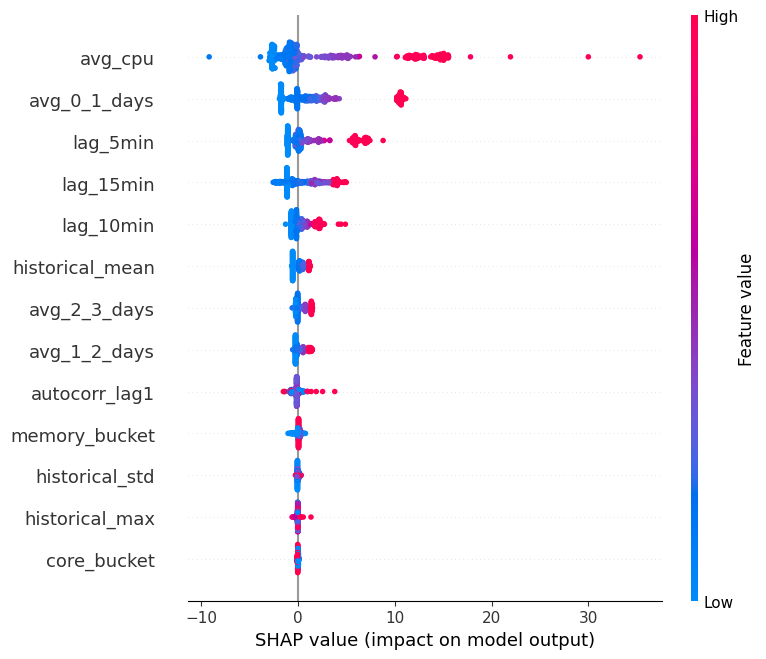

Top 10 features:
            feature  shap_importance
0           avg_cpu         4.139786
9      avg_0_1_days         3.125396
3          lag_5min         1.750052
5         lag_15min         1.749548
4         lag_10min         0.775812
6   historical_mean         0.530378
11     avg_2_3_days         0.468089
10     avg_1_2_days         0.444969
12    autocorr_lag1         0.279607
2     memory_bucket         0.154447


In [7]:
print("=== ЗАДАЧА 1: ПРОГНОЗ НА 5 МИНУТ (target_5min) С CATBOOST ===\n")

train_df = pd.read_parquet('train_df.parquet')
test_df = pd.read_parquet('test_df.parquet')

train_df = train_df[(train_df['core_bucket'] != '>24') & (train_df['memory_bucket'] != '>64')]
test_df = test_df[(test_df['core_bucket'] != '>24') & (test_df['memory_bucket'] != '>64')]

train_df['core_bucket'] = pd.to_numeric(train_df['core_bucket'])
train_df['memory_bucket'] = pd.to_numeric(train_df['memory_bucket'])
test_df['core_bucket'] = pd.to_numeric(test_df['core_bucket'])
test_df['memory_bucket'] = pd.to_numeric(test_df['memory_bucket'])

feature_cols = ['avg_cpu', 'core_bucket', 'memory_bucket', 'lag_5min', 'lag_10min', 'lag_15min',
                'historical_mean', 'historical_std', 'historical_max', 'avg_0_1_days',
                'avg_1_2_days', 'avg_2_3_days', 'autocorr_lag1']

target_col = 'target_5min'

X_train, X_test, y_train, y_test, imputer, scaler = prepare_features(train_df, test_df, feature_cols, target_col)

X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

print("CatBoost без тюнинга (базовые параметры):")
cb_default = CatBoostRegressor(iterations=300, depth=6, learning_rate=0.05, verbose=False, random_seed=42)
cb_default.fit(X_train, y_train)
pred_default = cb_default.predict(X_test)
evaluate_model(y_test, pred_default, "CatBoost (5min) - default")

print("\n=== Optuna тюнинг для CatBoost ===\n")
best_params, best_value = tune_catboost(X_tr, y_tr, X_val, y_val, n_trials=15)
print(f"Best params: {best_params}")
print(f"Best val MAE: {best_value:.4f}")

cb_best = CatBoostRegressor(**best_params, verbose=False, random_seed=42)
cb_best.fit(X_train, y_train)
pred_best = cb_best.predict(X_test)
evaluate_model(y_test, pred_best, "CatBoost (5min) - tuned")

print("\nSHAP Analysis:")
importance_df, _ = explain_with_shap(cb_best, X_test[:500], feature_cols)
print("Top 10 features:")
print(importance_df.head(10))

=== ЗАДАЧА 2: ПРОГНОЗ МАКСИМУМА ЗА 24 ЧАСА (target_24h) С CATBOOST ===

CatBoost без тюнинга (базовые параметры):


[I 2026-05-27 12:15:44,940] A new study created in memory with name: no-name-27a414a1-3841-444d-8aa3-6b648bf079e1



CatBoost (24h) - default
MAE:  2.460380
RMSE: 6.719870
R2:   0.729380
SVR (недооценка): 33.13% (65792/198611)
OVR (переоценка): 66.87% (132819/198611)

=== Optuna тюнинг для CatBoost ===



Best trial: 0. Best value: 2.40396:   7%|▋         | 1/15 [00:10<02:29, 10.65s/it]

[I 2026-05-27 12:15:55,587] Trial 0 finished with value: 2.4039628476721164 and parameters: {'iterations': 250, 'depth': 10, 'learning_rate': 0.05395030966670229, 'l2_leaf_reg': 6.387926357773329}. Best is trial 0 with value: 2.4039628476721164.


...

[I 2026-05-27 12:17:42,802] Trial 12 finished with value: 2.3696577074339826 and parameters: {'iterations': 500, 'depth': 8, 'learning_rate': 0.09858632185164357, 'l2_leaf_reg': 7.0164298800690945}. Best is trial 11 with value: 2.3460180426666764.


Best trial: 11. Best value: 2.34602:  93%|█████████▎| 14/15 [02:12<00:13, 13.33s/it]

[I 2026-05-27 12:17:57,066] Trial 13 finished with value: 2.3705277092321695 and parameters: {'iterations': 500, 'depth': 9, 'learning_rate': 0.06507547631899815, 'l2_leaf_reg': 7.227974223127852}. Best is trial 11 with value: 2.3460180426666764.


Best trial: 11. Best value: 2.34602: 100%|██████████| 15/15 [02:31<00:00, 10.08s/it]


[I 2026-05-27 12:18:16,126] Trial 14 finished with value: 2.357838766358527 and parameters: {'iterations': 450, 'depth': 10, 'learning_rate': 0.07105089399830998, 'l2_leaf_reg': 7.836931920718491}. Best is trial 11 with value: 2.3460180426666764.
Best params: {'iterations': 500, 'depth': 10, 'learning_rate': 0.07515866857795253, 'l2_leaf_reg': 6.741745796899547}
Best val MAE: 2.3460

CatBoost (24h) - tuned
MAE:  2.398268
RMSE: 6.643805
R2:   0.735472
SVR (недооценка): 34.51% (68535/198611)
OVR (переоценка): 65.49% (130076/198611)

SHAP Analysis:


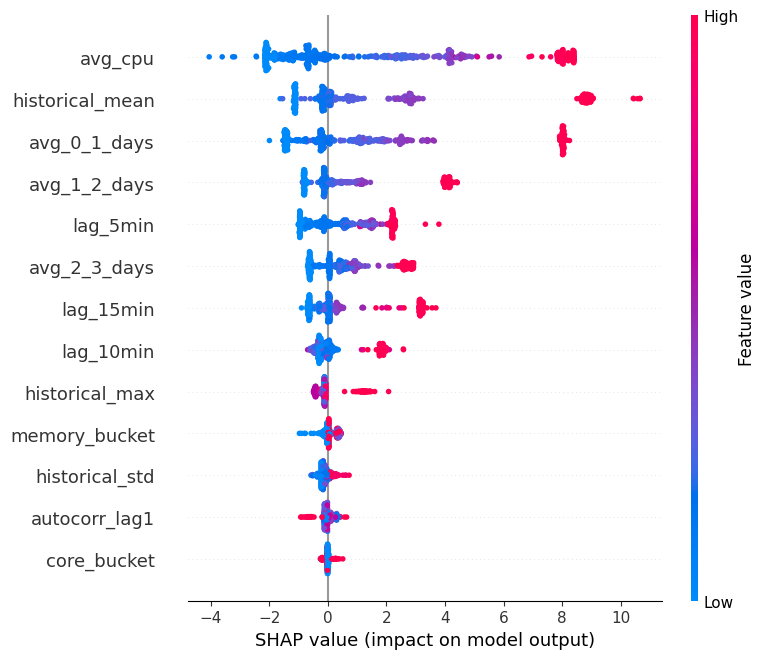

Top 10 features:
            feature  shap_importance
0           avg_cpu         3.123629
6   historical_mean         2.456709
9      avg_0_1_days         2.392767
10     avg_1_2_days         1.131893
3          lag_5min         1.025278
11     avg_2_3_days         0.946158
5         lag_15min         0.859153
4         lag_10min         0.532075
8    historical_max         0.308912
2     memory_bucket         0.170045


In [8]:
print("=== ЗАДАЧА 2: ПРОГНОЗ МАКСИМУМА ЗА 24 ЧАСА (target_24h) С CATBOOST ===\n")

train_df = pd.read_parquet('train_df.parquet')
test_df = pd.read_parquet('test_df.parquet')

train_df = train_df[(train_df['core_bucket'] != '>24') & (train_df['memory_bucket'] != '>64')]
test_df = test_df[(test_df['core_bucket'] != '>24') & (test_df['memory_bucket'] != '>64')]

train_df['core_bucket'] = pd.to_numeric(train_df['core_bucket'])
train_df['memory_bucket'] = pd.to_numeric(train_df['memory_bucket'])
test_df['core_bucket'] = pd.to_numeric(test_df['core_bucket'])
test_df['memory_bucket'] = pd.to_numeric(test_df['memory_bucket'])

feature_cols = ['avg_cpu', 'core_bucket', 'memory_bucket', 'lag_5min', 'lag_10min', 'lag_15min',
                'historical_mean', 'historical_std', 'historical_max', 'avg_0_1_days',
                'avg_1_2_days', 'avg_2_3_days', 'autocorr_lag1']

target_col = 'target_24h'

X_train, X_test, y_train, y_test, imputer, scaler = prepare_features(train_df, test_df, feature_cols, target_col)

X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

print("CatBoost без тюнинга (базовые параметры):")
cb_default = CatBoostRegressor(iterations=300, depth=6, learning_rate=0.05, verbose=False, random_seed=42)
cb_default.fit(X_train, y_train)
pred_default = cb_default.predict(X_test)
evaluate_model(y_test, pred_default, "CatBoost (24h) - default")

print("\n=== Optuna тюнинг для CatBoost ===\n")
best_params, best_value = tune_catboost(X_tr, y_tr, X_val, y_val, n_trials=15)
print(f"Best params: {best_params}")
print(f"Best val MAE: {best_value:.4f}")

cb_best = CatBoostRegressor(**best_params, verbose=False, random_seed=42)
cb_best.fit(X_train, y_train)
pred_best = cb_best.predict(X_test)
evaluate_model(y_test, pred_best, "CatBoost (24h) - tuned")

print("\nSHAP Analysis:")
importance_df, _ = explain_with_shap(cb_best, X_test[:500], feature_cols)
print("Top 10 features:")
print(importance_df.head(10))

=== ЗАДАЧА 3: ПРОГНОЗ НА ВЕСЬ СРОК ЖИЗНИ (target_lifetime_mean) С CATBOOST ===

Ridge Regression (базовая модель):

Ridge (lifetime)
MAE:  1.500888
RMSE: 3.867930
R2:   0.869517
SVR (недооценка): 36.52% (72529/198611)
OVR (переоценка): 63.48% (126082/198611)

Random Forest (базовые параметры):

Random Forest (lifetime) - default
MAE:  1.208285
RMSE: 3.703600
R2:   0.880369
SVR (недооценка): 37.14% (73762/198611)
OVR (переоценка): 62.86% (124849/198611)

CatBoost без тюнинга (базовые параметры):


[I 2026-05-27 12:22:47,913] A new study created in memory with name: no-name-a10133e1-0f55-4e46-a1b9-8312b864732d



CatBoost (lifetime) - default
MAE:  1.258190
RMSE: 3.539517
R2:   0.890734
SVR (недооценка): 34.93% (69377/198611)
OVR (переоценка): 65.07% (129234/198611)

=== Optuna тюнинг для CatBoost ===



Best trial: 0. Best value: 1.09864:   7%|▋         | 1/15 [00:10<02:27, 10.55s/it]

[I 2026-05-27 12:22:58,460] Trial 0 finished with value: 1.0986406144919771 and parameters: {'iterations': 250, 'depth': 10, 'learning_rate': 0.05395030966670229, 'l2_leaf_reg': 6.387926357773329}. Best is trial 0 with value: 1.0986406144919771.


...

[I 2026-05-27 12:24:45,748] Trial 12 finished with value: 1.019675788505202 and parameters: {'iterations': 500, 'depth': 8, 'learning_rate': 0.09858632185164357, 'l2_leaf_reg': 7.0164298800690945}. Best is trial 11 with value: 0.9721035029509322.


Best trial: 11. Best value: 0.972104:  93%|█████████▎| 14/15 [02:12<00:13, 13.40s/it]

[I 2026-05-27 12:25:00,175] Trial 13 finished with value: 1.025917113277826 and parameters: {'iterations': 500, 'depth': 9, 'learning_rate': 0.06507547631899815, 'l2_leaf_reg': 7.227974223127852}. Best is trial 11 with value: 0.9721035029509322.


Best trial: 11. Best value: 0.972104: 100%|██████████| 15/15 [02:31<00:00, 10.08s/it]


[I 2026-05-27 12:25:19,089] Trial 14 finished with value: 0.9958942304369617 and parameters: {'iterations': 450, 'depth': 10, 'learning_rate': 0.07105089399830998, 'l2_leaf_reg': 7.836931920718491}. Best is trial 11 with value: 0.9721035029509322.
Best params: {'iterations': 500, 'depth': 10, 'learning_rate': 0.07515866857795253, 'l2_leaf_reg': 6.741745796899547}
Best val MAE: 0.9721

CatBoost (lifetime) - tuned
MAE:  1.214302
RMSE: 3.492060
R2:   0.893644
SVR (недооценка): 38.32% (76110/198611)
OVR (переоценка): 61.68% (122501/198611)

Ensemble (Random Forest + CatBoost + Ridge):

Ensemble (lifetime)
MAE:  1.232376
RMSE: 3.480748
R2:   0.894332
SVR (недооценка): 32.92% (65387/198611)
OVR (переоценка): 67.08% (133224/198611)

SHAP Analysis:


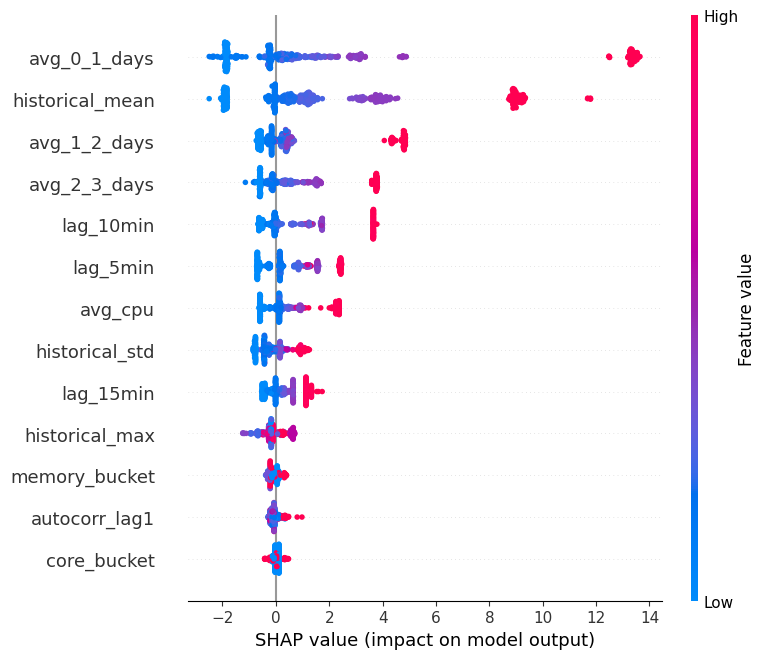

Top 10 features:
            feature  shap_importance
9      avg_0_1_days         3.541070
6   historical_mean         2.948232
10     avg_1_2_days         1.175870
11     avg_2_3_days         1.159595
4         lag_10min         1.113322
3          lag_5min         0.944084
0           avg_cpu         0.744197
7    historical_std         0.497908
5         lag_15min         0.458634
8    historical_max         0.346394


In [9]:
print("=== ЗАДАЧА 3: ПРОГНОЗ НА ВЕСЬ СРОК ЖИЗНИ (target_lifetime_mean) С CATBOOST ===\n")

train_df = pd.read_parquet('train_df.parquet')
test_df = pd.read_parquet('test_df.parquet')

train_df = train_df[(train_df['core_bucket'] != '>24') & (train_df['memory_bucket'] != '>64')]
test_df = test_df[(test_df['core_bucket'] != '>24') & (test_df['memory_bucket'] != '>64')]

train_df['core_bucket'] = pd.to_numeric(train_df['core_bucket'])
train_df['memory_bucket'] = pd.to_numeric(train_df['memory_bucket'])
test_df['core_bucket'] = pd.to_numeric(test_df['core_bucket'])
test_df['memory_bucket'] = pd.to_numeric(test_df['memory_bucket'])

feature_cols = ['avg_cpu', 'core_bucket', 'memory_bucket', 'lag_5min', 'lag_10min', 'lag_15min',
                'historical_mean', 'historical_std', 'historical_max', 'avg_0_1_days',
                'avg_1_2_days', 'avg_2_3_days', 'autocorr_lag1']

target_col = 'target_lifetime_mean'

X_train, X_test, y_train, y_test, imputer, scaler = prepare_features(train_df, test_df, feature_cols, target_col)

X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

print("Ridge Regression (базовая модель):")
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
pred_ridge = ridge.predict(X_test)
evaluate_model(y_test, pred_ridge, "Ridge (lifetime)")

print("\nRandom Forest (базовые параметры):")
rf_default = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
rf_default.fit(X_train, y_train)
pred_rf = rf_default.predict(X_test)
evaluate_model(y_test, pred_rf, "Random Forest (lifetime) - default")

print("\nCatBoost без тюнинга (базовые параметры):")
cb_default = CatBoostRegressor(iterations=300, depth=6, learning_rate=0.05, verbose=False, random_seed=42)
cb_default.fit(X_train, y_train)
pred_cb_default = cb_default.predict(X_test)
evaluate_model(y_test, pred_cb_default, "CatBoost (lifetime) - default")

print("\n=== Optuna тюнинг для CatBoost ===\n")
best_params, best_value = tune_catboost(X_tr, y_tr, X_val, y_val, n_trials=15)
print(f"Best params: {best_params}")
print(f"Best val MAE: {best_value:.4f}")

cb_best = CatBoostRegressor(**best_params, verbose=False, random_seed=42)
cb_best.fit(X_train, y_train)
pred_cb_best = cb_best.predict(X_test)
evaluate_model(y_test, pred_cb_best, "CatBoost (lifetime) - tuned")

print("\nEnsemble (Random Forest + CatBoost + Ridge):")
pred_ensemble = (pred_rf + pred_cb_best + pred_ridge) / 3
evaluate_model(y_test, pred_ensemble, "Ensemble (lifetime)")

print("\nSHAP Analysis:")
importance_df, _ = explain_with_shap(cb_best, X_test[:500], feature_cols)
print("Top 10 features:")
print(importance_df.head(10))

Бизнес-метрики

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


requested = test_df['core_bucket'].values

tasks_data = {
    'Задача 1: 5 минут': {
        'Linear Regression':   {'svr': 42.08},
        'RF default':          {'svr': 31.33},
        'RF tuned':            {'svr': 30.87},
        'CatBoost default':    {'svr': 35.80},
        'CatBoost tuned':      {'svr': 34.37},
    },
    'Задача 2: 24 часа': {
        'Linear Regression':   {'svr': 30.29},
        'RF tuned':            {'svr': 32.88},
        'CatBoost default':    {'svr': 33.13},
        'CatBoost tuned':      {'svr': 34.51},
    },
    'Задача 3: lifetime': {
        'Ridge':               {'svr': 36.52},
        'RF default':          {'svr': 37.14},
        'RF tuned':            {'svr': 38.05},
        'CatBoost default':    {'svr': 34.93},
        'CatBoost tuned':      {'svr': 38.32},
        'Ensemble':            {'svr': 32.92},
    },
}

# Savings для задачи 3 считаем из памяти
y = np.array(y_test)
savings_task3 = {
    'Ridge':            np.sum(pred_ridge)      / np.sum(requested[:len(y)]),
    'RF default':       np.sum(pred_rf)         / np.sum(requested[:len(y)]),
    'RF tuned':         np.sum(pred_rf_best)    / np.sum(requested[:len(y)]),
    'CatBoost default': np.sum(pred_cb_default) / np.sum(requested[:len(y)]),
    'CatBoost tuned':   np.sum(pred_cb_best)    / np.sum(requested[:len(y)]),
    'Ensemble':         np.sum(pred_ensemble)   / np.sum(requested[:len(y)]),
}
for name, val in savings_task3.items():
    tasks_data['Задача 3: lifetime'][name]['savings'] = val

# Savings для задач 1 и 2 — приближение через avg_cpu / core_bucket
# (среднее потребление от запрошенного)
avg_util = np.mean(test_df['avg_cpu'].values / test_df['core_bucket'].values)
for task in ['Задача 1: 5 минут', 'Задача 2: 24 часа']:
    for name in tasks_data[task]:
        tasks_data[task][name]['savings'] = avg_util


rows = []
for task, models in tasks_data.items():
    for model, vals in models.items():
        rows.append({'Задача': task, 'Модель': model,
                     'SVR, %': vals['svr'],
                     'Savings': round(vals.get('savings', float('nan')), 4)})

metrics_df = pd.DataFrame(rows)
print(metrics_df.to_string(index=False))

            Задача            Модель  SVR, %  Savings
 Задача 1: 5 минут Linear Regression   42.08   4.0738
 Задача 1: 5 минут        RF default   31.33   4.0738
 Задача 1: 5 минут          RF tuned   30.87   4.0738
 Задача 1: 5 минут  CatBoost default   35.80   4.0738
 Задача 1: 5 минут    CatBoost tuned   34.37   4.0738
 Задача 2: 24 часа Linear Regression   30.29   4.0738
 Задача 2: 24 часа          RF tuned   32.88   4.0738
 Задача 2: 24 часа  CatBoost default   33.13   4.0738
 Задача 2: 24 часа    CatBoost tuned   34.51   4.0738
Задача 3: lifetime             Ridge   36.52   3.3349
Задача 3: lifetime        RF default   37.14   3.3402
Задача 3: lifetime          RF tuned   38.05   3.3458
Задача 3: lifetime  CatBoost default   34.93   3.3332
Задача 3: lifetime    CatBoost tuned   38.32   3.3423
Задача 3: lifetime          Ensemble   32.92   3.3391


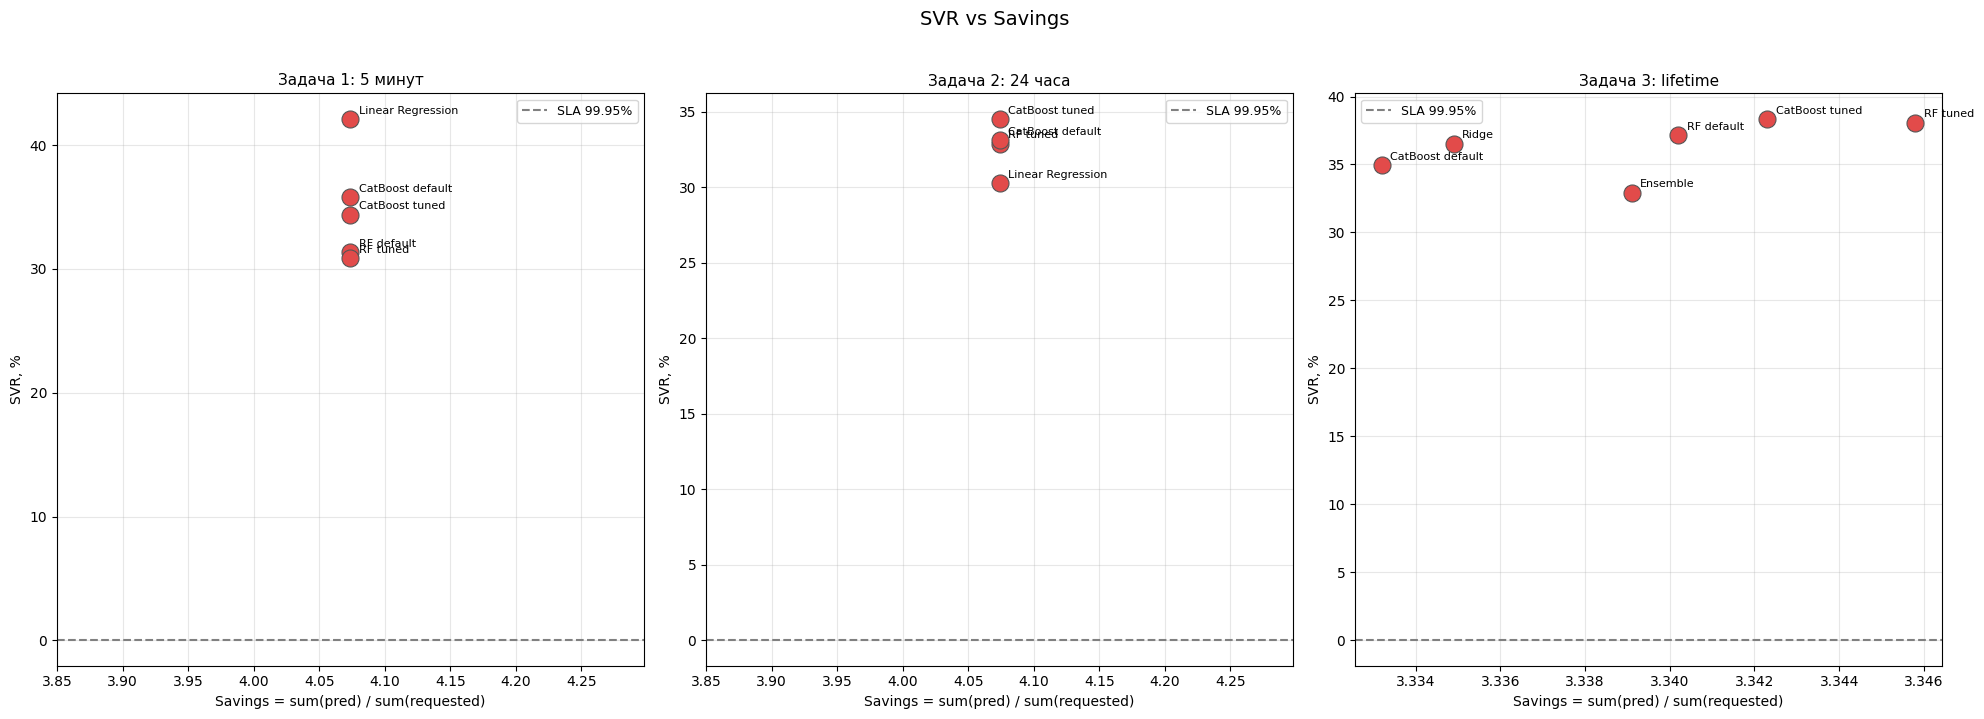

In [11]:
SLA_THRESHOLD = 0.05
tasks = list(tasks_data.keys())
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for ax, task in zip(axes, tasks):
    sub = metrics_df[metrics_df['Задача'] == task].reset_index(drop=True)
    for i, row in sub.iterrows():
        color = '#E24B4A' if row['SVR, %'] > SLA_THRESHOLD else '#1D9E75'
        ax.scatter(row['Savings'], row['SVR, %'],
                   color=color, s=150,
                   edgecolors='#555', linewidths=0.8, zorder=3)
        ax.annotate(row['Модель'],
                    (row['Savings'], row['SVR, %']),
                    textcoords='offset points',
                    xytext=(6, 4), fontsize=8)

    ax.axhline(y=SLA_THRESHOLD, color='gray', linestyle='--',
               linewidth=1.5, label='SLA 99.95%')
    ax.set_xlabel('Savings = sum(pred) / sum(requested)', fontsize=10)
    ax.set_ylabel('SVR, %', fontsize=10)
    ax.set_title(task, fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('SVR vs Savings', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('svr_vs_savings_all_tasks.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from catboost import CatBoostRegressor

# ==============================================================
# БИЗНЕС-МЕТРИКИ
# ==============================================================
train_df = pd.read_parquet('train_df.parquet')
test_df  = pd.read_parquet('test_df.parquet')
train_df = train_df[(train_df['core_bucket'] != '>24') & (train_df['memory_bucket'] != '>64')]
test_df  = test_df[(test_df['core_bucket']  != '>24') & (test_df['memory_bucket']  != '>64')]

train_df['core_bucket']   = pd.to_numeric(train_df['core_bucket'])
train_df['memory_bucket'] = pd.to_numeric(train_df['memory_bucket'])
test_df['core_bucket']    = pd.to_numeric(test_df['core_bucket'])
test_df['memory_bucket']  = pd.to_numeric(test_df['memory_bucket'])

feature_cols = ['avg_cpu', 'core_bucket', 'memory_bucket', 'lag_5min', 'lag_10min', 'lag_15min',
                'historical_mean', 'historical_std', 'historical_max',
                'avg_0_1_days', 'avg_1_2_days', 'avg_2_3_days', 'autocorr_lag1']

requested = test_df['core_bucket'].values

RF_PARAMS_5MIN = {'n_estimators': 150, 'max_depth': 20, 'min_samples_split': 16,
                  'min_samples_leaf': 10, 'max_features': None, 'random_state': 42, 'n_jobs': -1}
RF_PARAMS_24H  = {'n_estimators': 100, 'max_depth': 19, 'min_samples_split': 6,
                  'min_samples_leaf': 7,  'max_features': None, 'random_state': 42, 'n_jobs': -1}
RF_PARAMS_LT   = {'n_estimators': 100, 'max_depth': 19, 'min_samples_split': 6,
                  'min_samples_leaf': 7,  'max_features': None, 'random_state': 42, 'n_jobs': -1}
CB_PARAMS      = {'iterations': 500, 'depth': 10, 'learning_rate': 0.07515866857795253,
                  'l2_leaf_reg': 6.741745796899547, 'verbose': False, 'random_seed': 42}

def get_Xy(target_col):
    imp = SimpleImputer(strategy='median')
    sc  = StandardScaler()
    X_tr = sc.fit_transform(imp.fit_transform(train_df[feature_cols]))
    X_te = sc.transform(imp.transform(test_df[feature_cols]))
    return X_tr, X_te, train_df[target_col].values, test_df[target_col].values

def compute(task, model, y_true, y_pred):
    # SVR: доля наблюдений где модель недооценила реальное потребление (риск SLA)
    sv = np.mean(np.array(y_pred) < np.array(y_true)) * 100
    # Savings: sum(pred) / sum(core_bucket) — доля использования от верхней границы
    sa = np.sum(y_pred) / np.sum(requested[:len(y_pred)])
    print(f"  {model:<24}  SVR: {sv:.2f}%   Savings: {sa:.4f}")
    return {'task': task, 'model': model, 'svr': sv, 'savings': sa}
results = []
# ──────────────────────────────────────────────────────────────
# ТАРГЕТ: 5 МИНУТ 
# ──────────────────────────────────────────────────────────────
print("="*60)
print("  ТАРГЕТ: target_5min")
print("="*60)
X_tr, X_te, y_tr, y_te = get_Xy('target_5min')

p = LinearRegression().fit(X_tr, y_tr).predict(X_te)
results.append(compute('target_5min', 'Linear Regression', y_te, p))

p = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1).fit(X_tr, y_tr).predict(X_te)
results.append(compute('target_5min', 'RF default', y_te, p))

p = RandomForestRegressor(**RF_PARAMS_5MIN).fit(X_tr, y_tr).predict(X_te)
results.append(compute('target_5min', 'RF tuned', y_te, p))

p = CatBoostRegressor(iterations=300, depth=6, learning_rate=0.05, verbose=False, random_seed=42).fit(X_tr, y_tr).predict(X_te)
results.append(compute('target_5min', 'CatBoost default', y_te, p))

p = CatBoostRegressor(**CB_PARAMS).fit(X_tr, y_tr).predict(X_te)
results.append(compute('target_5min', 'CatBoost tuned', y_te, p))

# ──────────────────────────────────────────────────────────────
# ТАРГЕТ: 24Ч
# ──────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("  ТАРГЕТ: target_24h")
print("="*60)
X_tr, X_te, y_tr, y_te = get_Xy('target_24h')

p = LinearRegression().fit(X_tr, y_tr).predict(X_te)
results.append(compute('target_24h', 'Linear Regression', y_te, p))

p = RandomForestRegressor(**RF_PARAMS_24H).fit(X_tr, y_tr).predict(X_te)
results.append(compute('target_24h', 'RF tuned', y_te, p))

p = CatBoostRegressor(iterations=300, depth=6, learning_rate=0.05, verbose=False, random_seed=42).fit(X_tr, y_tr).predict(X_te)
results.append(compute('target_24h', 'CatBoost default', y_te, p))

p = CatBoostRegressor(**CB_PARAMS).fit(X_tr, y_tr).predict(X_te)
results.append(compute('target_24h', 'CatBoost tuned', y_te, p))

# ──────────────────────────────────────────────────────────────
# ТАРГЕТ: Inf
# ──────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("  ТАРГЕТ: target_lifetime_mean")
print("="*60)
X_tr, X_te, y_tr, y_te = get_Xy('target_lifetime_mean')

p_ridge = Ridge(alpha=1.0).fit(X_tr, y_tr).predict(X_te)
results.append(compute('target_lifetime', 'Ridge', y_te, p_ridge))

p_rf_def = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1).fit(X_tr, y_tr).predict(X_te)
results.append(compute('target_lifetime', 'RF default', y_te, p_rf_def))

p_rf_best = RandomForestRegressor(**RF_PARAMS_LT).fit(X_tr, y_tr).predict(X_te)
results.append(compute('target_lifetime', 'RF tuned', y_te, p_rf_best))

p_ens_rf = (p_rf_best + p_ridge) / 2
results.append(compute('target_lifetime', 'Ensemble (RF+Ridge)', y_te, p_ens_rf))

p_cb_def = CatBoostRegressor(iterations=300, depth=6, learning_rate=0.05, verbose=False, random_seed=42).fit(X_tr, y_tr).predict(X_te)
results.append(compute('target_lifetime', 'CatBoost default', y_te, p_cb_def))

p_cb_best = CatBoostRegressor(**CB_PARAMS).fit(X_tr, y_tr).predict(X_te)
results.append(compute('target_lifetime', 'CatBoost tuned', y_te, p_cb_best))

p_ens_full = (p_rf_best + p_cb_best + p_ridge) / 3
results.append(compute('target_lifetime', 'Ensemble (RF+CB+Ridge)', y_te, p_ens_full))

# ==============================================================
# СВОДНАЯ ТАБЛИЦА
# ==============================================================
metrics_df = pd.DataFrame(results)

print("\n\n" + "="*74)
print("  СВОДНАЯ ТАБЛИЦА БИЗНЕС-МЕТРИК")
print("="*74)
print(f"  {'Таргет':<18} {'Модель':<24} {'SVR, %':>9}  {'Savings':>9}")
print("-"*74)
for task in ['target_5min', 'target_24h', 'target_lifetime']:
    for _, row in metrics_df[metrics_df['task'] == task].iterrows():
        # лучшая модель по SVR в группе — отмечаем
        best_svr = metrics_df[metrics_df['task'] == task]['svr'].min()
        marker = ' ◄' if row['svr'] == best_svr else ''
        print(f"  {row['task']:<18} {row['model']:<24} {row['svr']:>8.2f}%  "
              f"{row['savings']:>9.4f}{marker}")
    print("-"*74)
print("="*74)
print("  SVR    — доля наблюдений с недооценкой потребления (риск нарушения SLA)")
print("  Savings — sum(pred) / sum(core_bucket): доля использования от верхней границы")

  ТАРГЕТ: target_5min
  Linear Regression         SVR: 42.08%   Savings: 3.3073
  RF default                SVR: 31.33%   Savings: 3.3122
  RF tuned                  SVR: 30.87%   Savings: 3.3120
  CatBoost default          SVR: 35.80%   Savings: 3.3081
  CatBoost tuned            SVR: 34.37%   Savings: 3.3079

  ТАРГЕТ: target_24h
  Linear Regression         SVR: 30.29%   Savings: 3.2988
  RF tuned                  SVR: 32.88%   Savings: 3.3095
  CatBoost default          SVR: 33.13%   Savings: 3.2946
  CatBoost tuned            SVR: 34.51%   Savings: 3.2955

  ТАРГЕТ: target_lifetime_mean
  Ridge                     SVR: 36.52%   Savings: 3.3349
  RF default                SVR: 37.14%   Savings: 3.3402
  RF tuned                  SVR: 38.05%   Savings: 3.3458
  Ensemble (RF+Ridge)       SVR: 34.33%   Savings: 3.3403
  CatBoost default          SVR: 34.93%   Savings: 3.3332
  CatBoost tuned            SVR: 38.32%   Savings: 3.3423
  Ensemble (RF+CB+Ridge)    SVR: 32.86%   Savings: 3.3

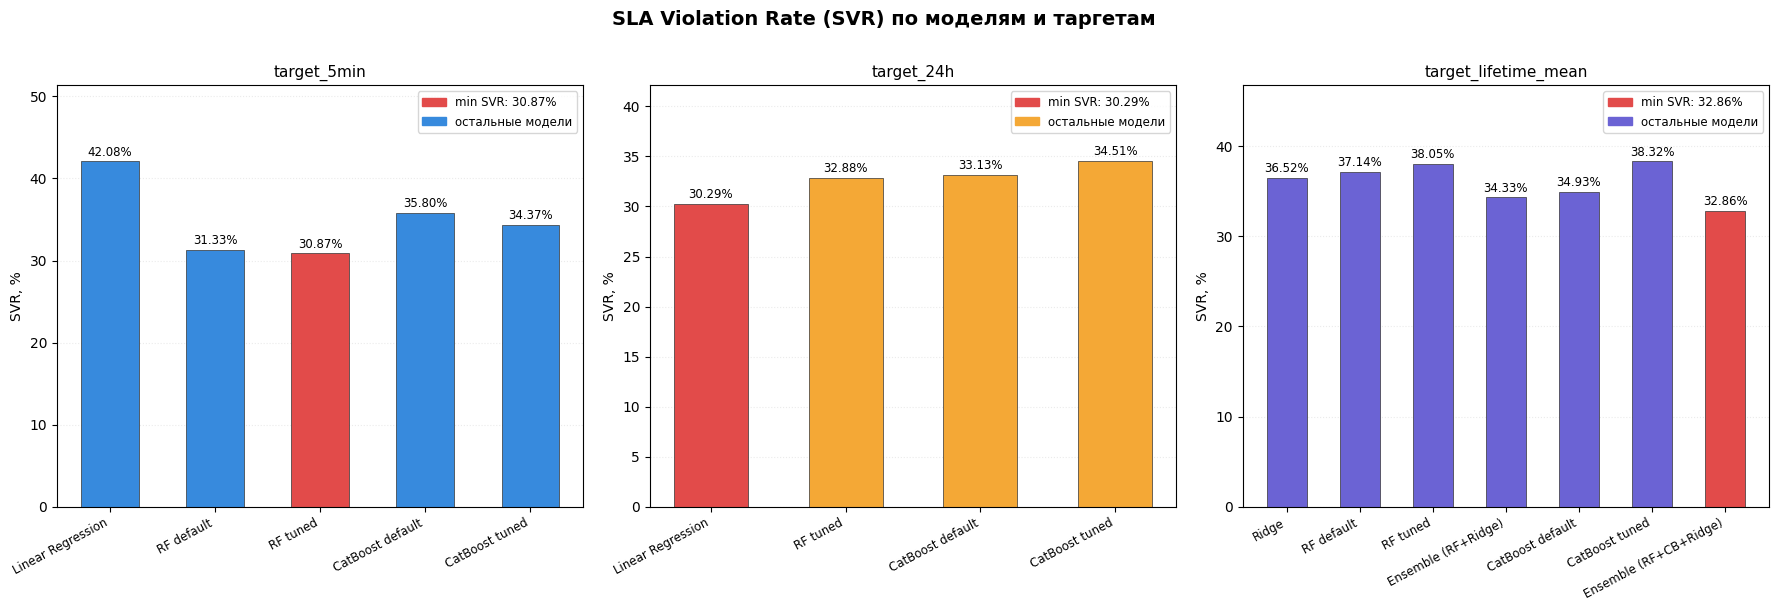

График сохранён: svr_bar_by_target.png


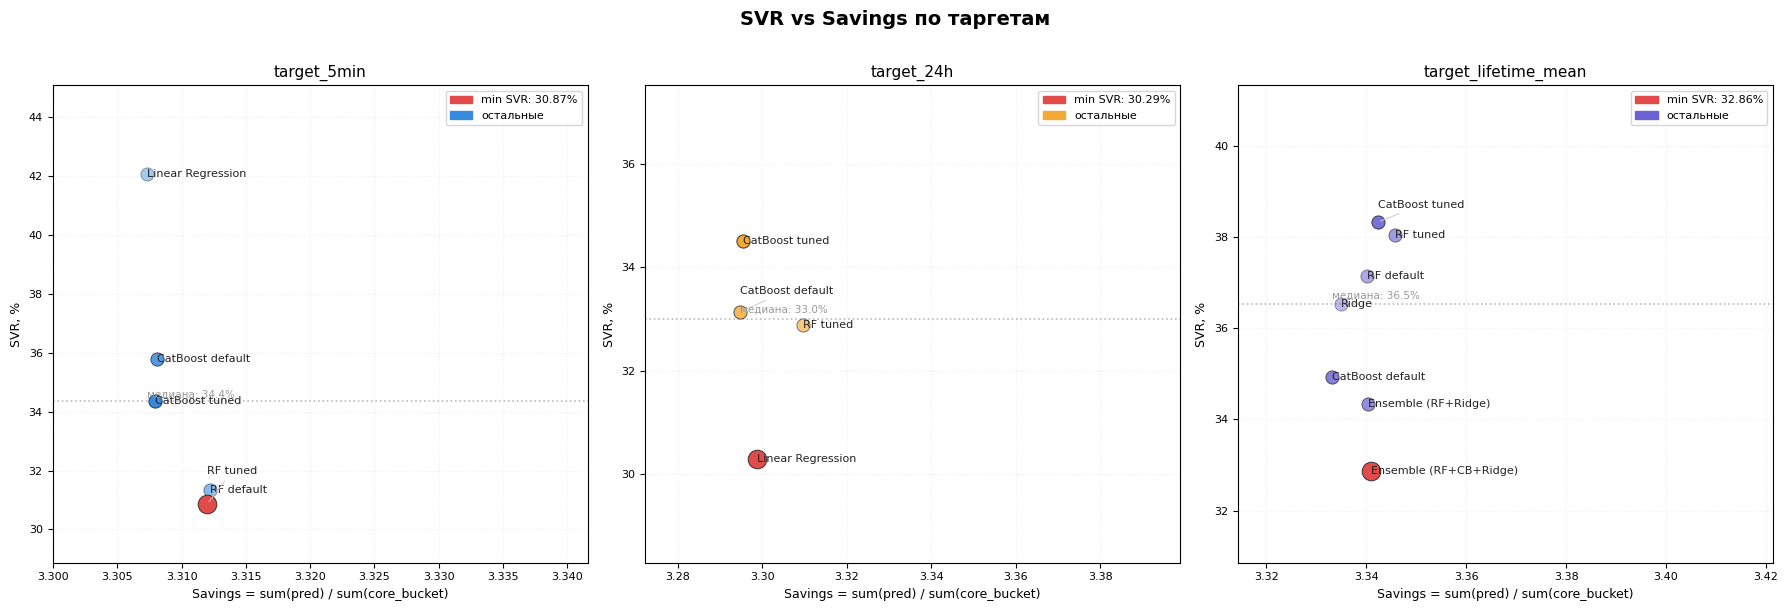

График сохранён: svr_vs_savings_by_target.png


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
#данные из аутпутов выше
data = {
    'target_5min': {
        'Linear Regression': {'svr': 42.08, 'savings': 3.3073, 'mae': 1.755, 'rmse': 4.133, 'r2': 0.897},
        'RF default':        {'svr': 31.33, 'savings': 3.3122, 'mae': 1.285, 'rmse': 3.646, 'r2': 0.920},
        'RF tuned':          {'svr': 30.87, 'savings': 3.3120, 'mae': 1.239, 'rmse': 3.607, 'r2': 0.922},
        'CatBoost default':  {'svr': 35.80, 'savings': 3.3081, 'mae': 1.387, 'rmse': 3.691, 'r2': 0.918},
        'CatBoost tuned':    {'svr': 34.37, 'savings': 3.3079, 'mae': 1.306, 'rmse': 3.596, 'r2': 0.922},
    },
    'target_24h': {
        'Linear Regression': {'svr': 30.29, 'savings': 3.2988, 'mae': 2.674, 'rmse': 6.944, 'r2': 0.711},
        'RF tuned':          {'svr': 32.88, 'savings': 3.3095, 'mae': 2.365, 'rmse': 6.664, 'r2': 0.734},
        'CatBoost default':  {'svr': 33.13, 'savings': 3.2946, 'mae': 2.460, 'rmse': 6.720, 'r2': 0.729},
        'CatBoost tuned':    {'svr': 34.51, 'savings': 3.2955, 'mae': 2.398, 'rmse': 6.644, 'r2': 0.735},
    },
    'target_lifetime_mean': {
        'Ridge':                  {'svr': 36.52, 'savings': 3.3349, 'mae': 1.501, 'rmse': 3.868, 'r2': 0.870},
        'RF default':             {'svr': 37.14, 'savings': 3.3402, 'mae': 1.208, 'rmse': 3.704, 'r2': 0.880},
        'RF tuned':               {'svr': 38.05, 'savings': 3.3458, 'mae': 1.207, 'rmse': 3.713, 'r2': 0.880},
        'Ensemble (RF+Ridge)':    {'svr': 34.33, 'savings': 3.3403, 'mae': 1.284, 'rmse': 3.581, 'r2': 0.888},
        'CatBoost default':       {'svr': 34.93, 'savings': 3.3332, 'mae': 1.258, 'rmse': 3.540, 'r2': 0.891},
        'CatBoost tuned':         {'svr': 38.32, 'savings': 3.3423, 'mae': 1.214, 'rmse': 3.492, 'r2': 0.894},
        'Ensemble (RF+CB+Ridge)': {'svr': 32.86, 'savings': 3.3410, 'mae': 1.232, 'rmse': 3.481, 'r2': 0.894},
    },
}

TASK_COLORS = {
    'target_5min':          '#378ADD',
    'target_24h':           '#F4A836',
    'target_lifetime_mean': '#6B63D4',
}
TASK_LABELS = {
    'target_5min':          'target_5min',
    'target_24h':           'target_24h',
    'target_lifetime_mean': 'target_lifetime_mean',
}
MODEL_PALETTE = [
    '#1A6BB5', '#378ADD', '#5BA3E8', '#80BDF0', '#A8D4F7',
    '#6B63D4', '#9B94E0',
]


# ==============================================================
# ГРАФИК 1: SVR BAR CHART
# ==============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('SLA Violation Rate (SVR) по моделям и таргетам',
             fontsize=14, fontweight='bold', y=1.01)

for ax, (task, label) in zip(axes, TASK_LABELS.items()):
    models = list(data[task].keys())
    values = [data[task][m]['svr'] for m in models]
    best   = min(values)
    x      = np.arange(len(models))
    colors = ['#E24B4A' if v == best else TASK_COLORS[task] for v in values]

    bars = ax.bar(x, values, color=colors, edgecolor='#333',
                  linewidth=0.5, width=0.55, zorder=2)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.3,
                f'{val:.2f}%', ha='center', va='bottom', fontsize=8.5)

    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=28, ha='right', fontsize=8.5)
    ax.set_ylabel('SVR, %', fontsize=10)
    ax.set_title(label, fontsize=11, fontweight='medium')
    ax.set_ylim(0, max(values) * 1.22)
    ax.grid(axis='y', alpha=0.25, linestyle=':')

    best_patch = mpatches.Patch(color='#E24B4A', label=f'min SVR: {best:.2f}%')
    rest_patch = mpatches.Patch(color=TASK_COLORS[task], label='остальные модели')
    ax.legend(handles=[best_patch, rest_patch], fontsize=8.5)

plt.tight_layout()
plt.savefig('svr_bar_by_target.png', dpi=150, bbox_inches='tight')
plt.show()
print("График сохранён: svr_bar_by_target.png")


# ==============================================================
# ГРАФИК 2: SVR vs SAVINGS — простые круги, подписи сбоку
# ==============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('SVR vs Savings по таргетам',
             fontsize=14, fontweight='bold', y=1.01)

for ax, (task, label) in zip(axes, TASK_LABELS.items()):
    models = list(data[task].keys())
    svrs   = [data[task][m]['svr']     for m in models]
    savs   = [data[task][m]['savings'] for m in models]
    best   = min(svrs)

    base   = TASK_COLORS[task]
    n      = len(models)
    alphas = np.linspace(0.45, 1.0, n)

    for i, (m, sv, sa) in enumerate(zip(models, svrs, savs)):
        is_best = sv == best
        color   = '#E24B4A' if is_best else TASK_COLORS[task]
        alpha   = 1.0 if is_best else alphas[i]
        size    = 180 if is_best else 90
        ax.scatter(sa, sv, color=color, s=size, alpha=alpha,
                   edgecolors='#333', linewidths=0.7, zorder=3)


    used_y = []
    for i, (m, sv, sa) in enumerate(zip(models, svrs, savs)):
        y_text = sv
        for y_used in used_y:
            if abs(y_text - y_used) < 0.6:
                y_text = y_used + 0.65
        used_y.append(y_text)
        ax.annotate(m, xy=(sa, sv), xytext=(sa, y_text),
                    fontsize=8, color='#222', ha='left', va='center',
                    arrowprops=dict(arrowstyle='-', color='#ccc', lw=0.7)
                    if abs(y_text - sv) > 0.2 else None)

    med = np.median(svrs)
    ax.axhline(med, color='#bbb', linestyle=':', linewidth=1.2)
    ax.text(min(savs), med + 0.12, f'медиана: {med:.1f}%', fontsize=7.5, color='#999')

    xpad = max((max(savs) - min(savs)) * 1.5, 0.005)
    ax.set_xlim(min(savs) - xpad, max(savs) + xpad * 4)
    ax.set_ylim(min(svrs) - 2, max(svrs) + 3)
    ax.set_xlabel('Savings = sum(pred) / sum(core_bucket)', fontsize=9)
    ax.set_ylabel('SVR, %', fontsize=9)
    ax.set_title(label, fontsize=11, fontweight='medium')
    ax.grid(True, alpha=0.2, linestyle=':')
    ax.tick_params(labelsize=8)

    best_patch = mpatches.Patch(color='#E24B4A', label=f'min SVR: {best:.2f}%')
    rest_patch = mpatches.Patch(color=TASK_COLORS[task], label='остальные')
    ax.legend(handles=[best_patch, rest_patch], fontsize=8)

plt.tight_layout()
plt.savefig('svr_vs_savings_by_target.png', dpi=150, bbox_inches='tight')
plt.show()
print("График сохранён: svr_vs_savings_by_target.png")

Модели обучены.


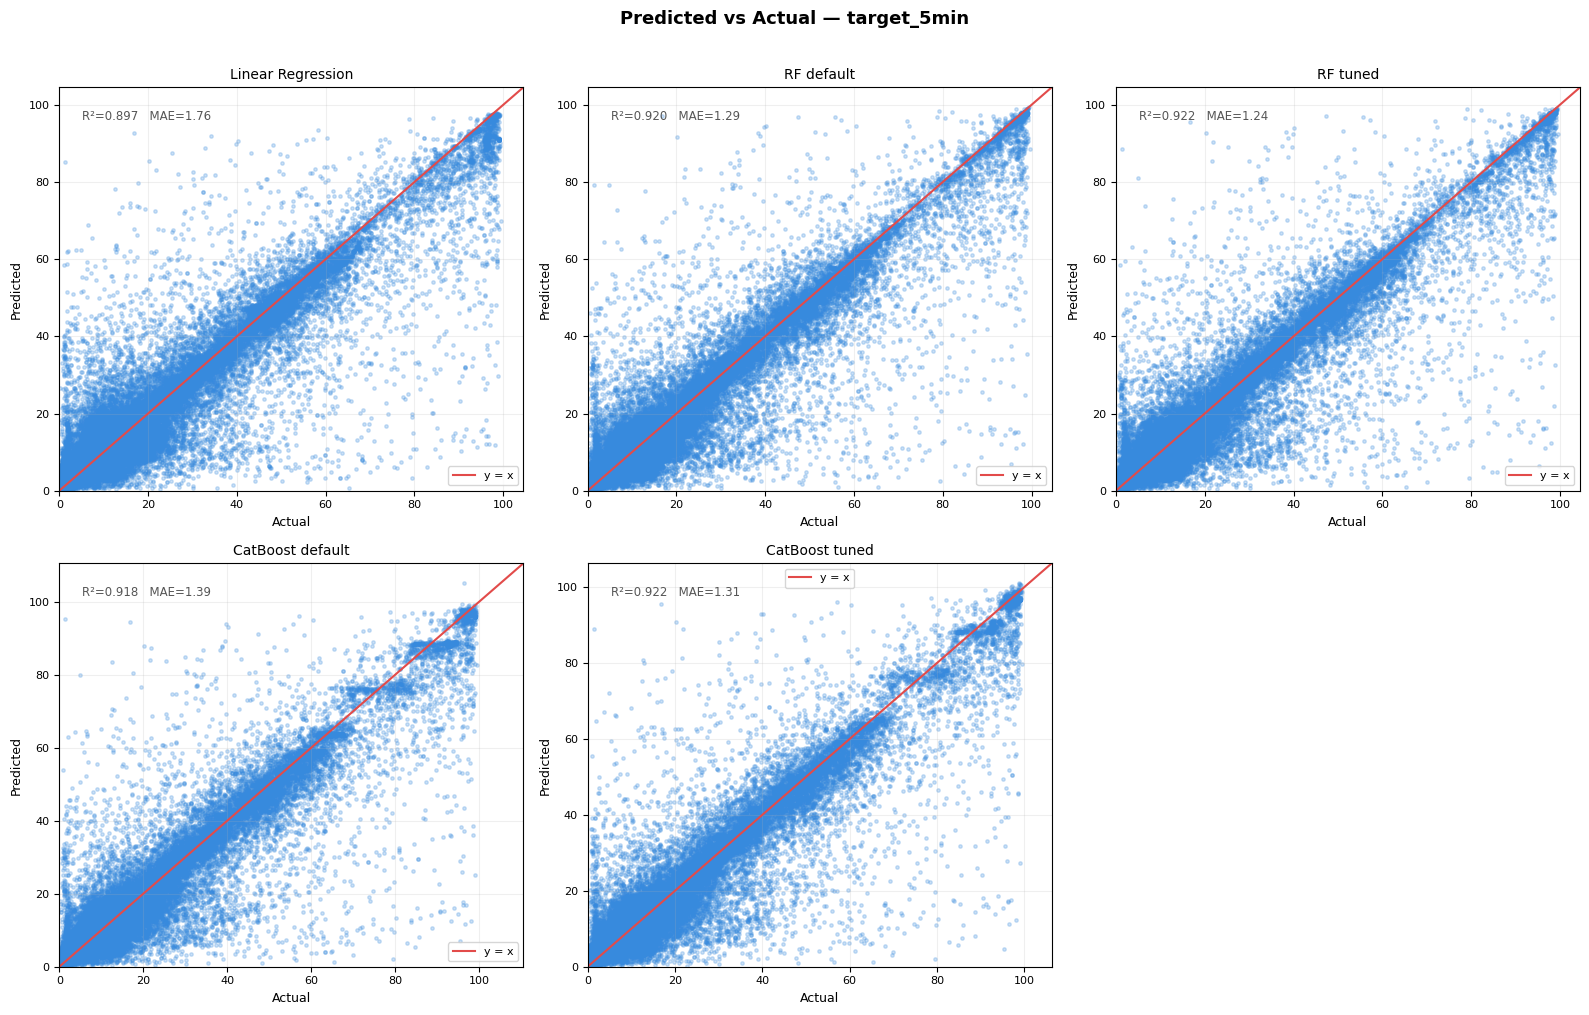

График сохранён: predicted_vs_actual_target_5min.png


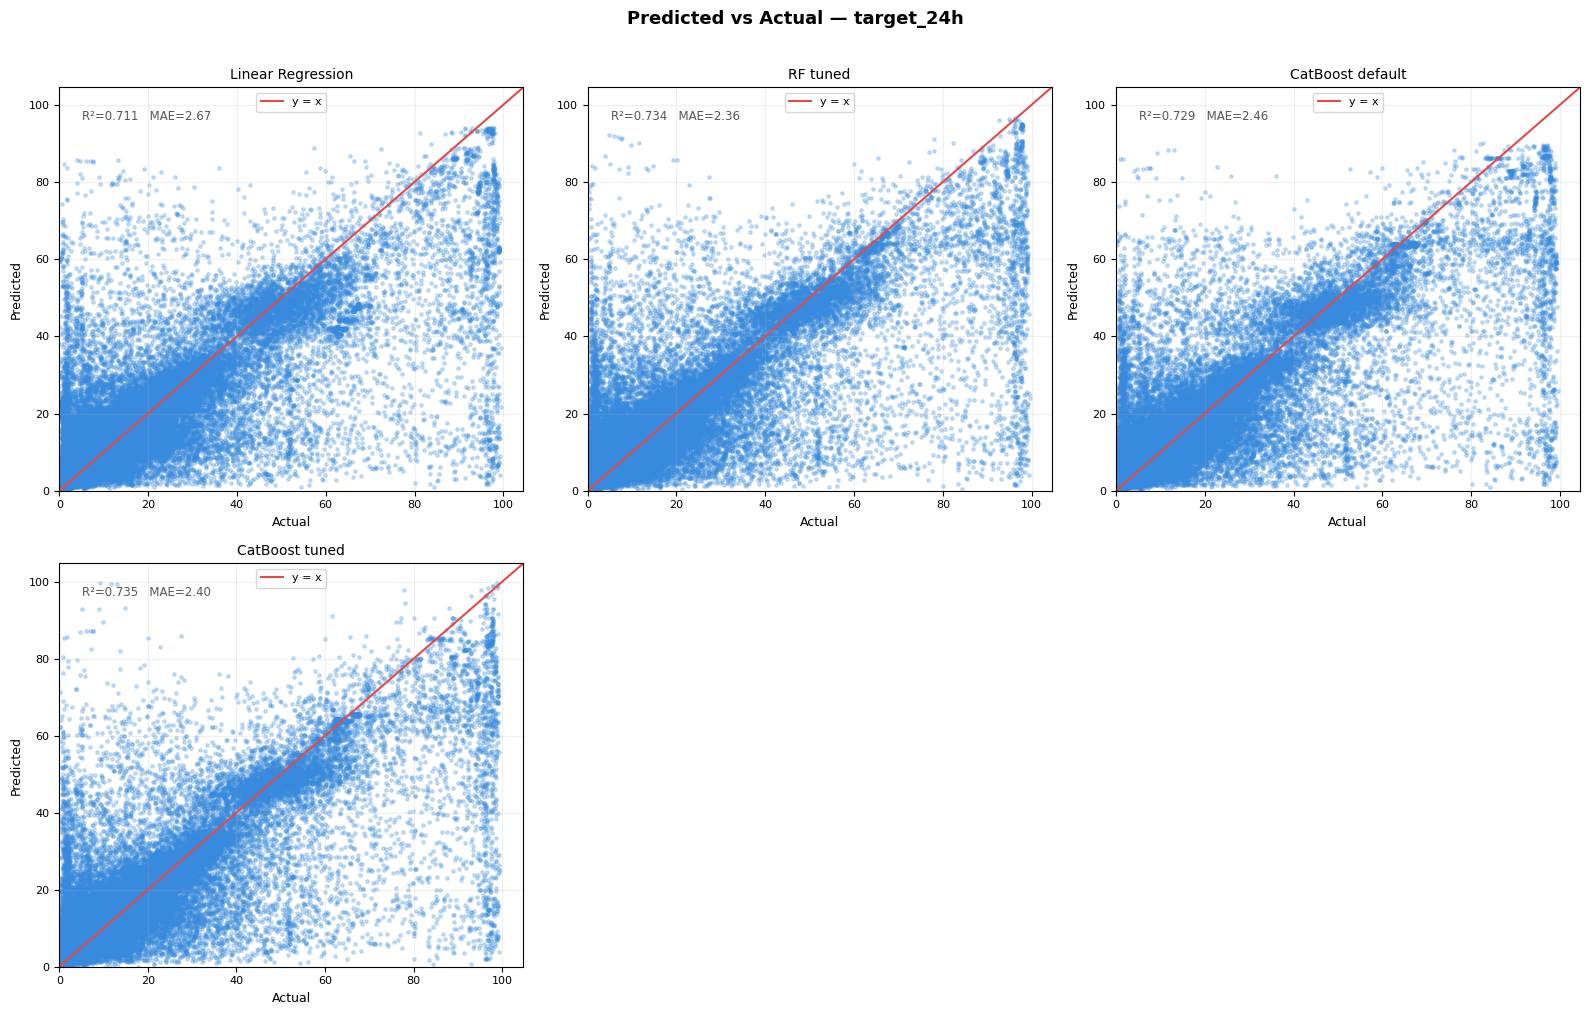

График сохранён: predicted_vs_actual_target_24h.png


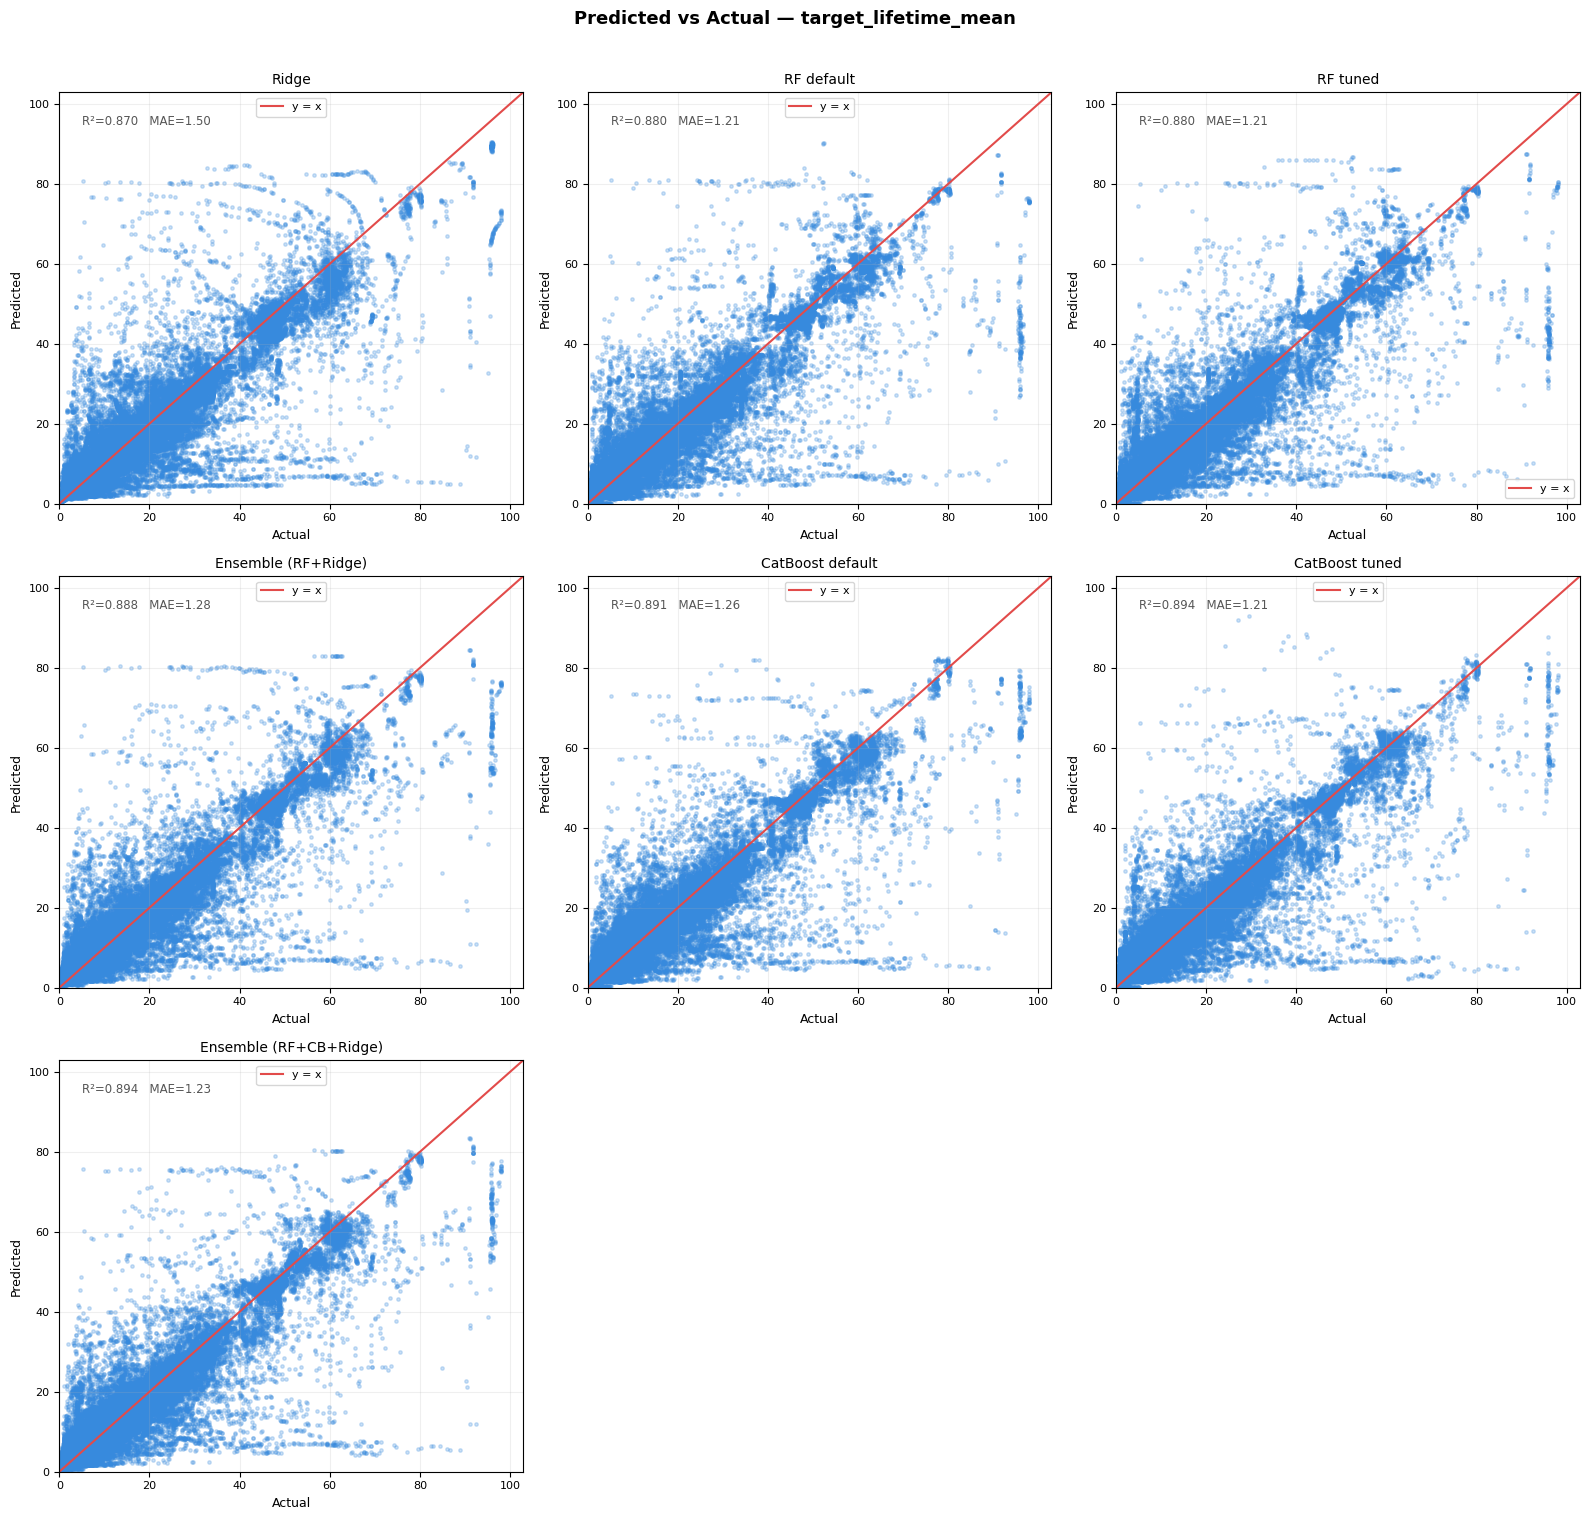

График сохранён: predicted_vs_actual_target_lifetime_mean.png


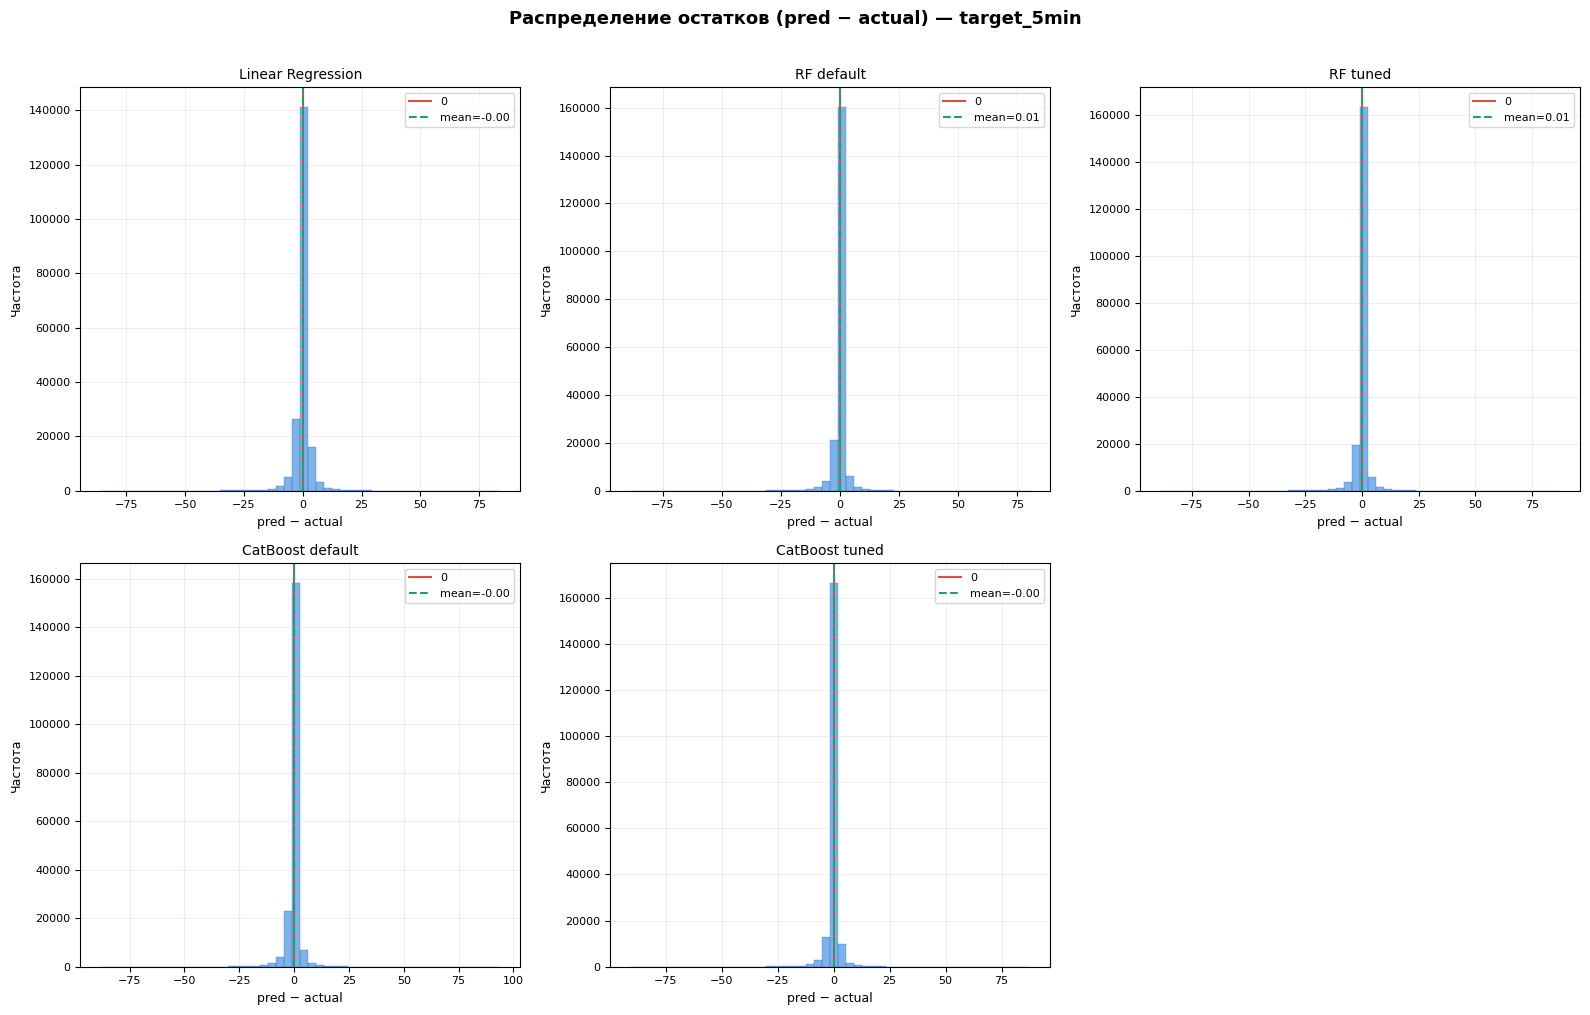

График сохранён: residuals_target_5min.png


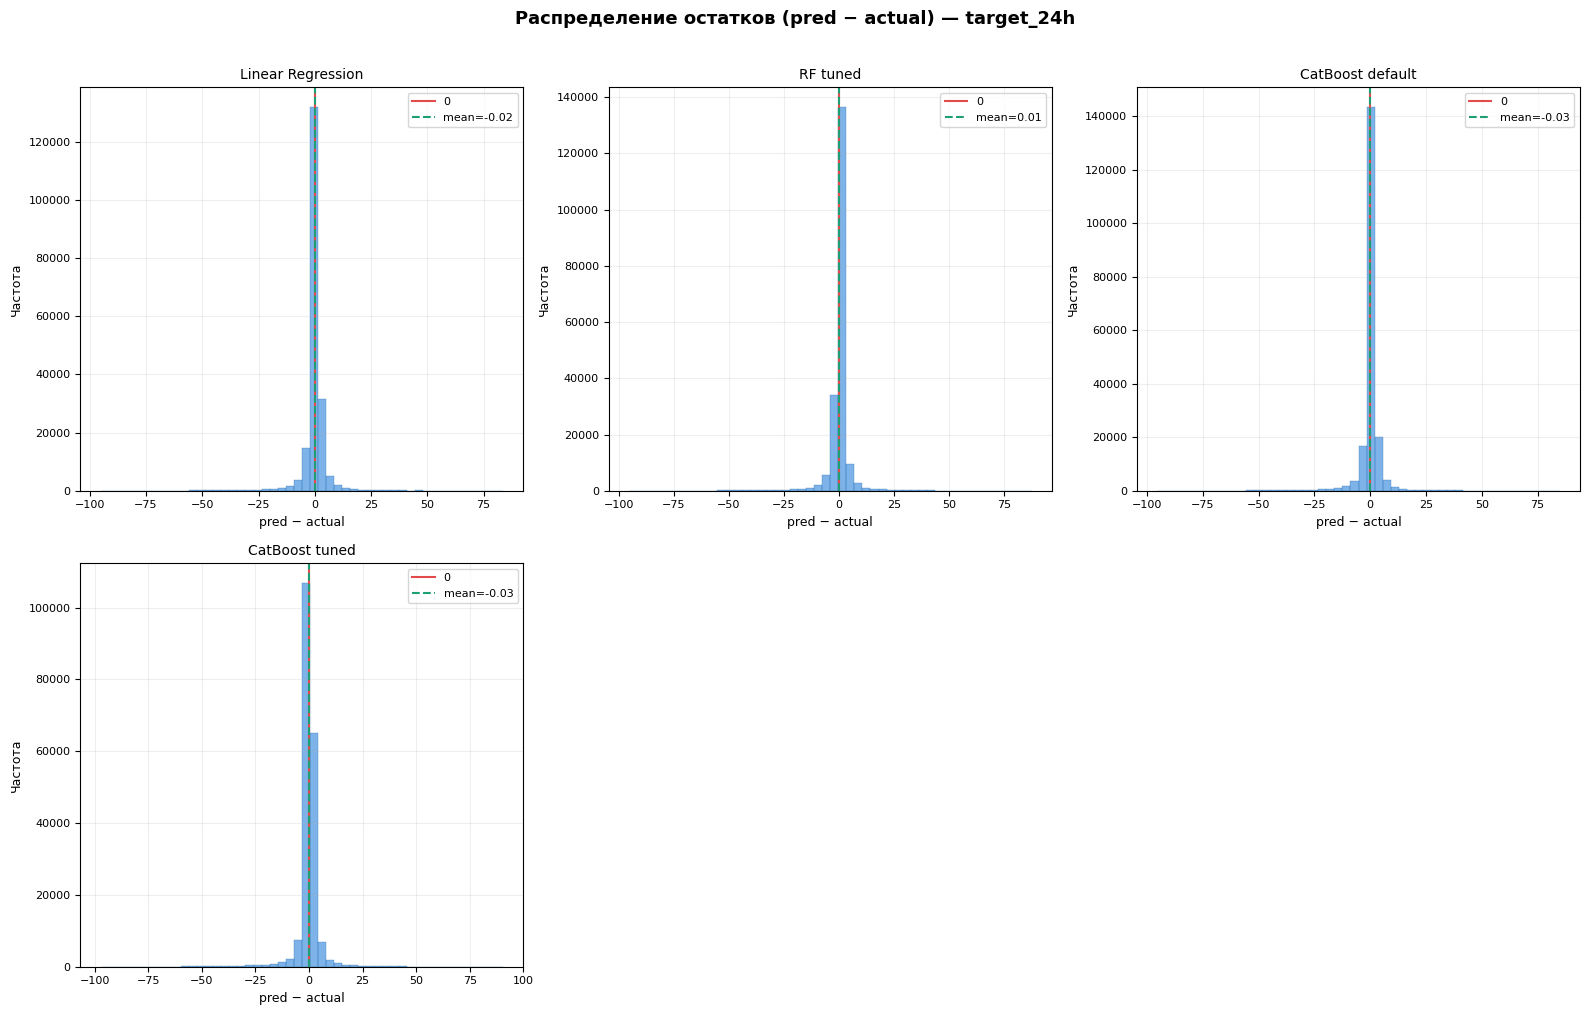

График сохранён: residuals_target_24h.png


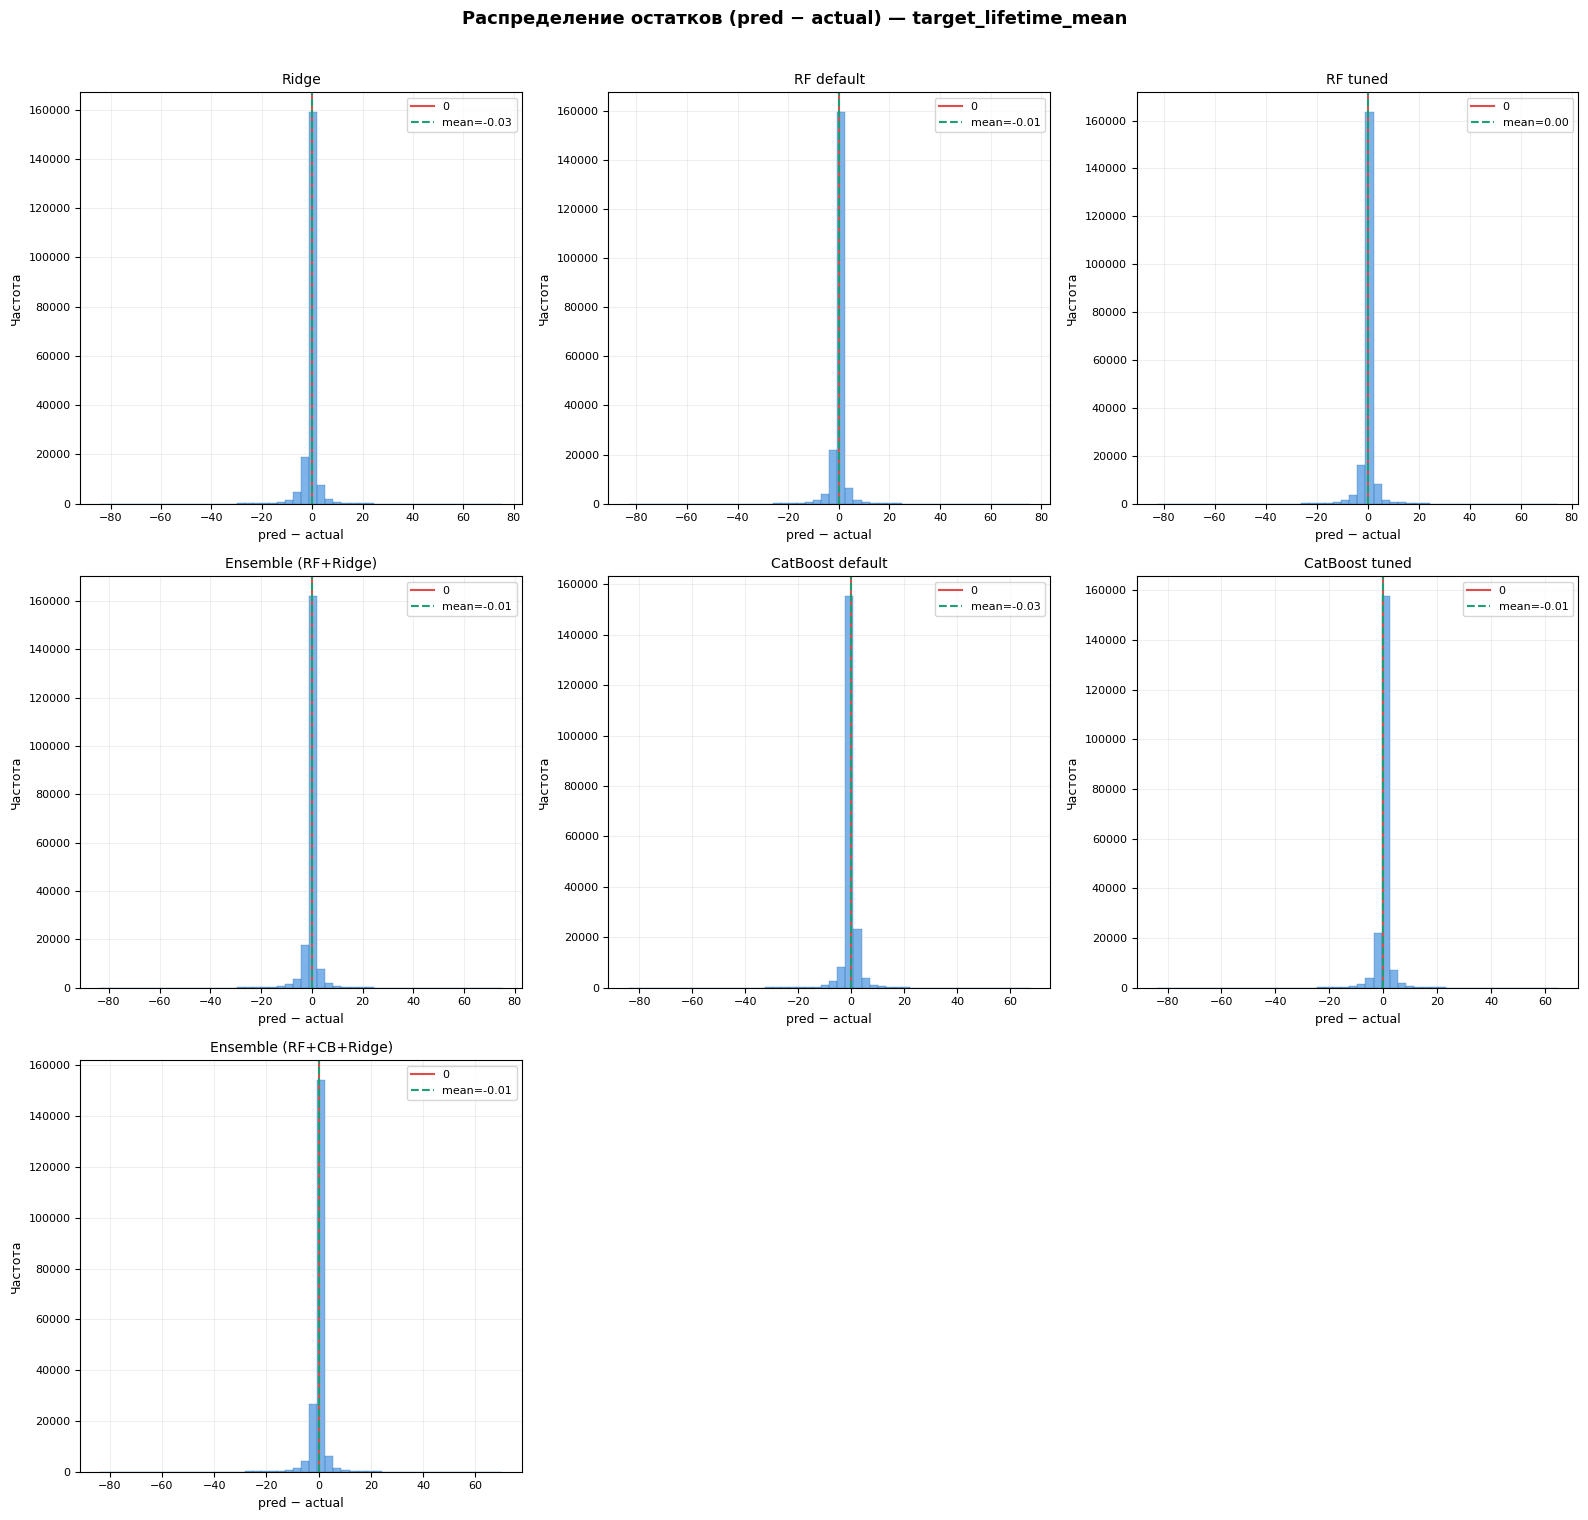

График сохранён: residuals_target_lifetime_mean.png


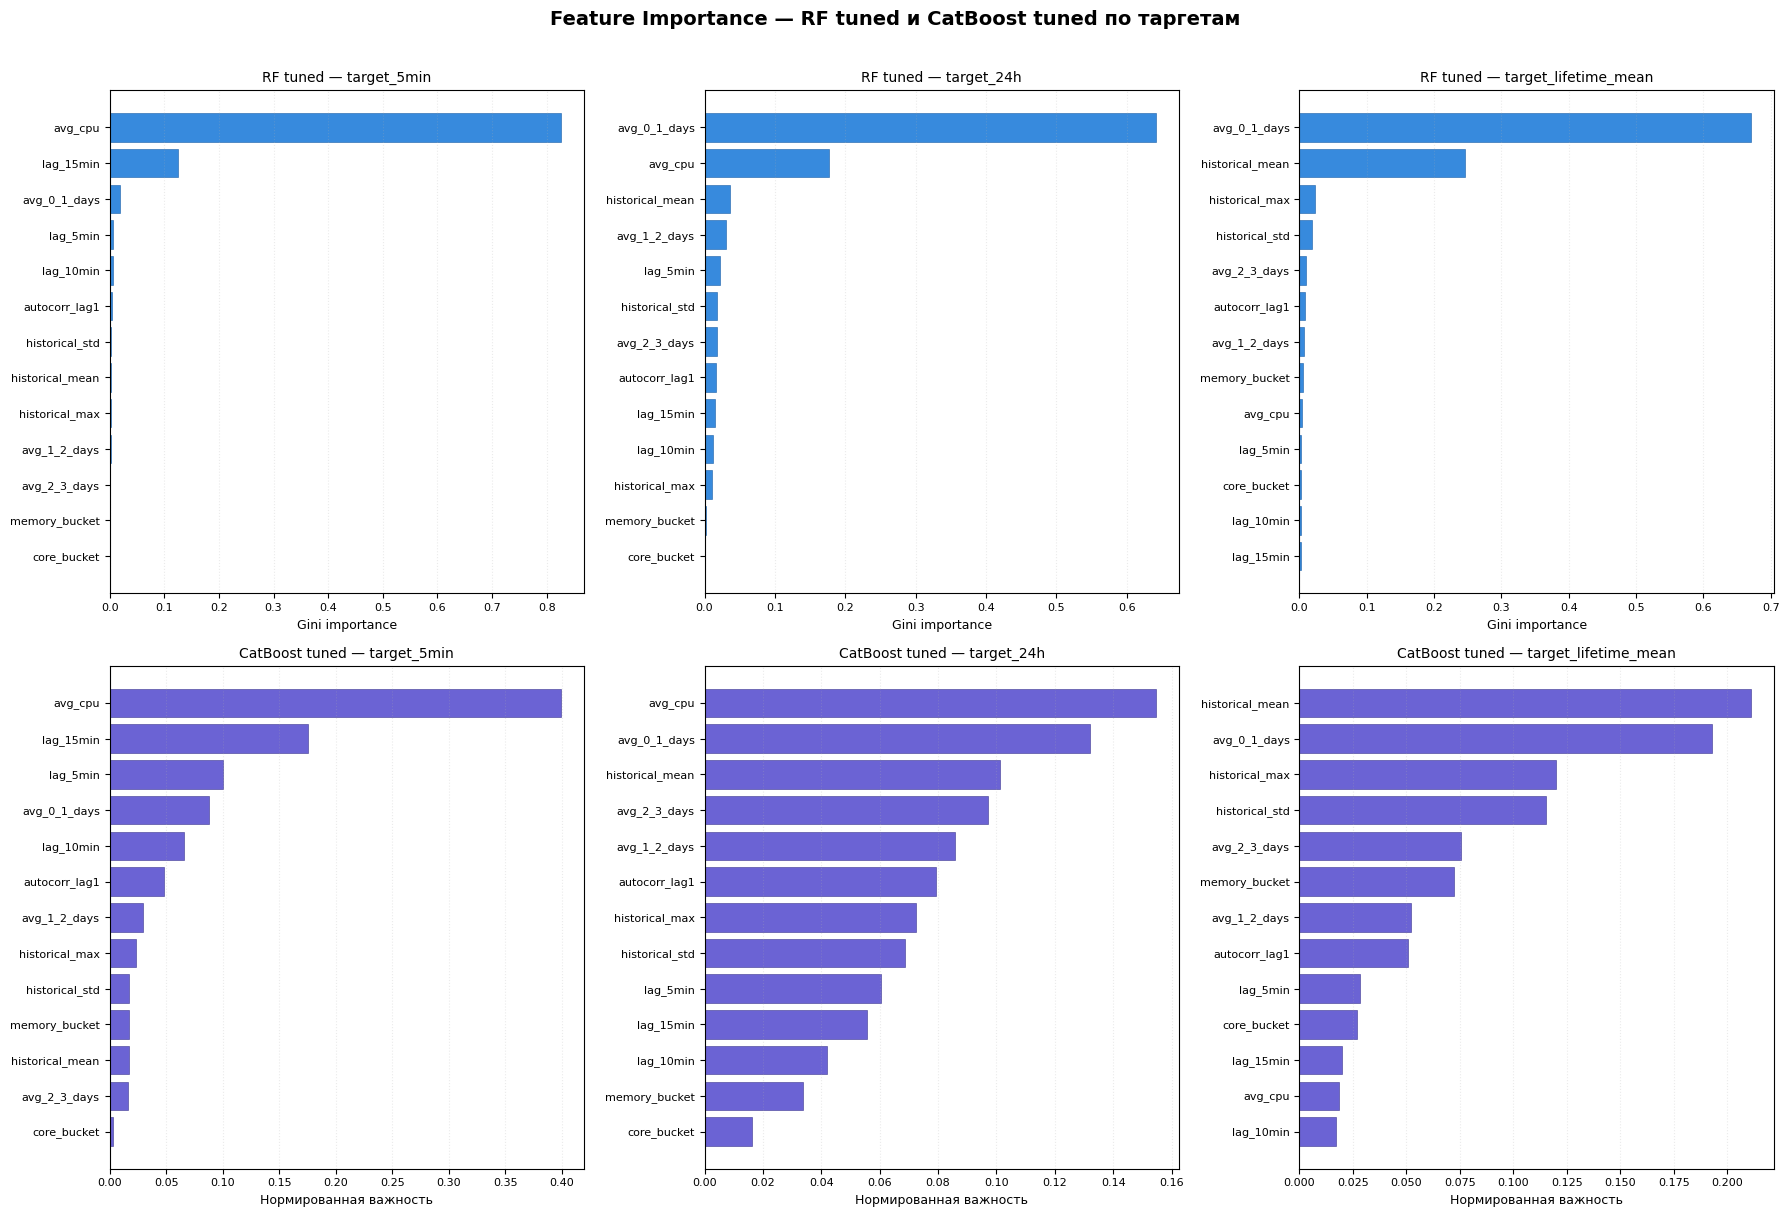

График сохранён: feature_importance_all_targets.png


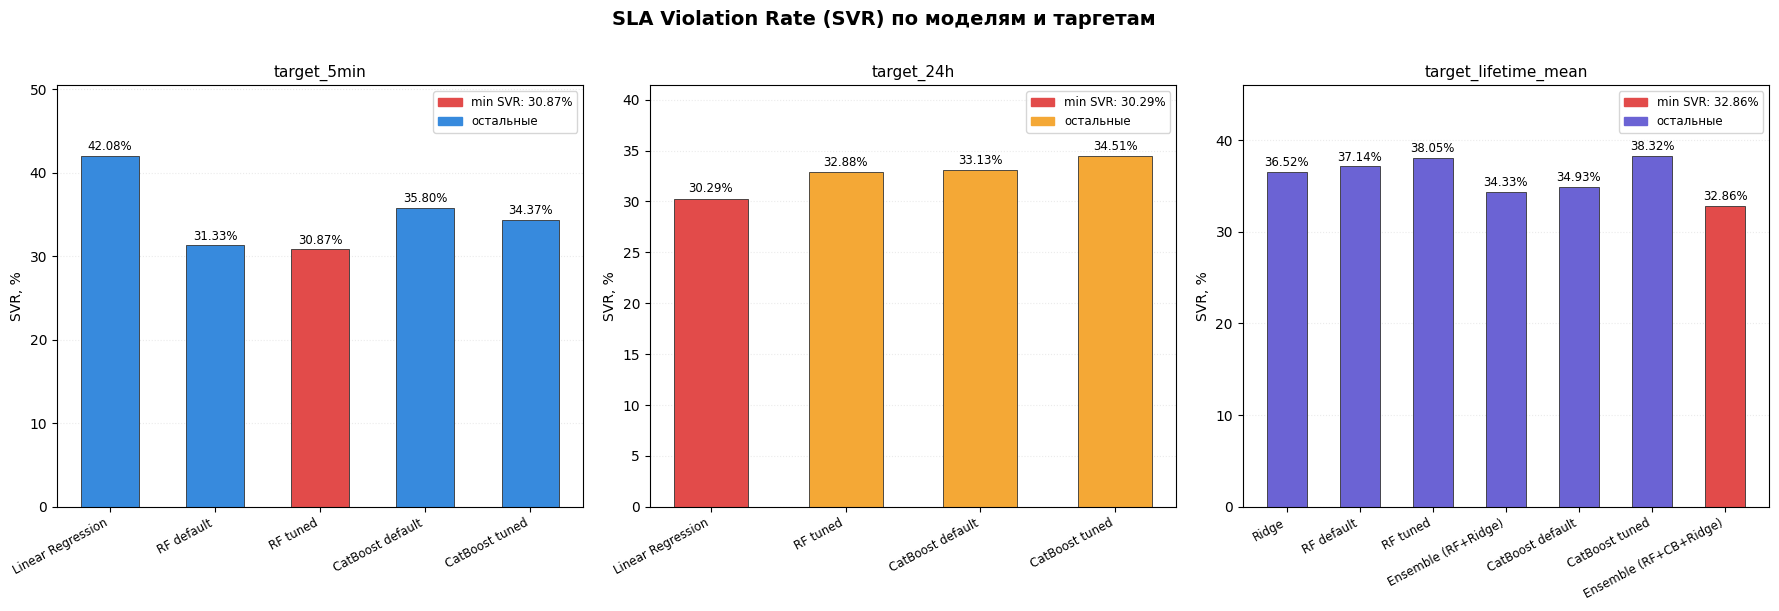

График сохранён: svr_bar_by_target.png


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from catboost import CatBoostRegressor
train_df = pd.read_parquet('train_df.parquet')
test_df  = pd.read_parquet('test_df.parquet')

train_df = train_df[(train_df['core_bucket'] != '>24') & (train_df['memory_bucket'] != '>64')]
test_df  = test_df[(test_df['core_bucket']  != '>24') & (test_df['memory_bucket']  != '>64')]

train_df['core_bucket']   = pd.to_numeric(train_df['core_bucket'])
train_df['memory_bucket'] = pd.to_numeric(train_df['memory_bucket'])
test_df['core_bucket']    = pd.to_numeric(test_df['core_bucket'])
test_df['memory_bucket']  = pd.to_numeric(test_df['memory_bucket'])

feature_cols = ['avg_cpu', 'core_bucket', 'memory_bucket', 'lag_5min', 'lag_10min', 'lag_15min',
                'historical_mean', 'historical_std', 'historical_max',
                'avg_0_1_days', 'avg_1_2_days', 'avg_2_3_days', 'autocorr_lag1']

RF_PARAMS_5MIN = {'n_estimators': 150, 'max_depth': 20, 'min_samples_split': 16,
                  'min_samples_leaf': 10, 'max_features': None, 'random_state': 42, 'n_jobs': -1}
RF_PARAMS_24H  = {'n_estimators': 100, 'max_depth': 19, 'min_samples_split': 6,
                  'min_samples_leaf': 7,  'max_features': None, 'random_state': 42, 'n_jobs': -1}
RF_PARAMS_LT   = {'n_estimators': 100, 'max_depth': 19, 'min_samples_split': 6,
                  'min_samples_leaf': 7,  'max_features': None, 'random_state': 42, 'n_jobs': -1}
CB_PARAMS      = {'iterations': 500, 'depth': 10, 'learning_rate': 0.07515866857795253,
                  'l2_leaf_reg': 6.741745796899547, 'verbose': False, 'random_seed': 42}
CB_DEF         = {'iterations': 300, 'depth': 6, 'learning_rate': 0.05,
                  'verbose': False, 'random_seed': 42}

def get_Xy(target_col):
    imp = SimpleImputer(strategy='median')
    sc  = StandardScaler()
    X_tr = sc.fit_transform(imp.fit_transform(train_df[feature_cols]))
    X_te = sc.transform(imp.transform(test_df[feature_cols]))
    return X_tr, X_te, train_df[target_col].values, test_df[target_col].values

all_preds = {}

for target, rf_params in [('target_5min', RF_PARAMS_5MIN),
                           ('target_24h',  RF_PARAMS_24H),
                           ('target_lifetime_mean', RF_PARAMS_LT)]:
    X_tr, X_te, y_tr, y_te = get_Xy(target)
    preds = {}

    if target == 'target_lifetime_mean':
        p_ridge = Ridge(alpha=1.0).fit(X_tr, y_tr).predict(X_te)
        preds['Ridge'] = p_ridge
    else:
        p_lr = LinearRegression().fit(X_tr, y_tr).predict(X_te)
        preds['Linear Regression'] = p_lr

    p_rf_def = RandomForestRegressor(n_estimators=200, max_depth=15,
                                     random_state=42, n_jobs=-1).fit(X_tr, y_tr).predict(X_te)
    if target != 'target_24h':
        preds['RF default'] = p_rf_def

    p_rf_best = RandomForestRegressor(**rf_params).fit(X_tr, y_tr).predict(X_te)
    preds['RF tuned'] = p_rf_best

    if target == 'target_lifetime_mean':
        preds['Ensemble (RF+Ridge)'] = (p_rf_best + p_ridge) / 2

    p_cb_def = CatBoostRegressor(**CB_DEF).fit(X_tr, y_tr).predict(X_te)
    preds['CatBoost default'] = p_cb_def

    p_cb_best = CatBoostRegressor(**CB_PARAMS).fit(X_tr, y_tr).predict(X_te)
    preds['CatBoost tuned'] = p_cb_best

    if target == 'target_lifetime_mean':
        preds['Ensemble (RF+CB+Ridge)'] = (p_rf_best + p_cb_best + p_ridge) / 3

    all_preds[target] = {'y_te': y_te, 'preds': preds,
                         'rf_model': RandomForestRegressor(**rf_params).fit(X_tr, y_tr),
                         'cb_model': CatBoostRegressor(**CB_PARAMS).fit(X_tr, y_tr)}

print("Модели обучены.")

TARGET_TITLES = {
    'target_5min':          'target_5min',
    'target_24h':           'target_24h',
    'target_lifetime_mean': 'target_lifetime_mean',
}


# ==============================================================
# ГРАФИК 1: PREDICTED VS ACTUAL — по таргетам
# ==============================================================

for target, title in TARGET_TITLES.items():
    preds_dict = all_preds[target]['preds']
    y_te       = all_preds[target]['y_te']
    n          = len(preds_dict)
    ncols      = 3
    nrows      = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 5 * nrows))
    axes = np.array(axes).flatten()
    fig.suptitle(f'Predicted vs Actual — {title}', fontsize=13, fontweight='bold', y=1.01)

    for i, (name, pred) in enumerate(preds_dict.items()):
        ax  = axes[i]
        lim = [0, max(y_te.max(), np.array(pred).max()) * 1.05]

        ax.scatter(y_te, pred, alpha=0.25, s=6, color='#378ADD')
        ax.plot(lim, lim, color='#E24B4A', linewidth=1.5, label='y = x')

        r2  = 1 - np.sum((y_te - pred)**2) / np.sum((y_te - np.mean(y_te))**2)
        mae = np.mean(np.abs(y_te - pred))

        ax.set_xlim(lim); ax.set_ylim(lim)
        ax.set_title(name, fontsize=10, fontweight='medium')
        ax.set_xlabel('Actual', fontsize=9)
        ax.set_ylabel('Predicted', fontsize=9)
        ax.text(0.05, 0.92, f'R²={r2:.3f}   MAE={mae:.2f}',
                transform=ax.transAxes, fontsize=8.5, color='#555')
        ax.legend(fontsize=8)
        ax.grid(alpha=0.2)
        ax.tick_params(labelsize=8)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.savefig(f'predicted_vs_actual_{target}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"График сохранён: predicted_vs_actual_{target}.png")


# ==============================================================
# ГРАФИК 2: РАСПРЕДЕЛЕНИЕ ОСТАТКОВ — по таргетам
# ==============================================================

for target, title in TARGET_TITLES.items():
    preds_dict = all_preds[target]['preds']
    y_te       = all_preds[target]['y_te']
    n          = len(preds_dict)
    ncols      = 3
    nrows      = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 5 * nrows))
    axes = np.array(axes).flatten()
    fig.suptitle(f'Распределение остатков (pred − actual) — {title}',
                 fontsize=13, fontweight='bold', y=1.01)

    for i, (name, pred) in enumerate(preds_dict.items()):
        ax        = axes[i]
        residuals = np.array(pred) - y_te

        ax.hist(residuals, bins=50, color='#378ADD', alpha=0.65,
                edgecolor='#185FA5', linewidth=0.3)
        ax.axvline(0, color='#E24B4A', linewidth=1.5, label='0')
        ax.axvline(residuals.mean(), color='#1D9E75', linewidth=1.5,
                   linestyle='--', label=f'mean={residuals.mean():.2f}')

        ax.set_title(name, fontsize=10, fontweight='medium')
        ax.set_xlabel('pred − actual', fontsize=9)
        ax.set_ylabel('Частота', fontsize=9)
        ax.legend(fontsize=8)
        ax.grid(alpha=0.2)
        ax.tick_params(labelsize=8)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.savefig(f'residuals_{target}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"График сохранён: residuals_{target}.png")


# ==============================================================
# ГРАФИК 3: FEATURE IMPORTANCE — RF tuned и CatBoost tuned
# ==============================================================

FEATURE_NAMES_RU = {
    'avg_cpu':          'avg_cpu',
    'core_bucket':      'core_bucket',
    'memory_bucket':    'memory_bucket',
    'lag_5min':         'lag_5min',
    'lag_10min':        'lag_10min',
    'lag_15min':        'lag_15min',
    'historical_mean':  'historical_mean',
    'historical_std':   'historical_std',
    'historical_max':   'historical_max',
    'avg_0_1_days':     'avg_0_1_days',
    'avg_1_2_days':     'avg_1_2_days',
    'avg_2_3_days':     'avg_2_3_days',
    'autocorr_lag1':    'autocorr_lag1',
}

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Feature Importance — RF tuned и CatBoost tuned по таргетам',
             fontsize=14, fontweight='bold', y=1.01)

for col, (target, title) in enumerate(TARGET_TITLES.items()):
    rf_model = all_preds[target]['rf_model']
    cb_model = all_preds[target]['cb_model']

    # RF
    ax_rf = axes[0][col]
    imp_rf = rf_model.feature_importances_
    idx_rf = np.argsort(imp_rf)
    ax_rf.barh([feature_cols[i] for i in idx_rf], imp_rf[idx_rf],
               color='#378ADD', edgecolor='#1A5FA8', linewidth=0.4)
    ax_rf.set_title(f'RF tuned — {title}', fontsize=10, fontweight='medium')
    ax_rf.set_xlabel('Gini importance', fontsize=9)
    ax_rf.tick_params(labelsize=8)
    ax_rf.grid(axis='x', alpha=0.25, linestyle=':')

    # CatBoost
    ax_cb = axes[1][col]
    imp_cb = cb_model.get_feature_importance()
    imp_cb_norm = imp_cb / imp_cb.sum()
    idx_cb = np.argsort(imp_cb_norm)
    ax_cb.barh([feature_cols[i] for i in idx_cb], imp_cb_norm[idx_cb],
               color='#6B63D4', edgecolor='#3D3690', linewidth=0.4)
    ax_cb.set_title(f'CatBoost tuned — {title}', fontsize=10, fontweight='medium')
    ax_cb.set_xlabel('Нормированная важность', fontsize=9)
    ax_cb.tick_params(labelsize=8)
    ax_cb.grid(axis='x', alpha=0.25, linestyle=':')

plt.tight_layout()
plt.savefig('feature_importance_all_targets.png', dpi=150, bbox_inches='tight')
plt.show()
print("График сохранён: feature_importance_all_targets.png")


# ==============================================================
# ГРАФИК 4: SVR BAR CHART
# ==============================================================

svr_data = {
    'target_5min': {
        'Linear Regression': 42.08, 'RF default': 31.33, 'RF tuned': 30.87,
        'CatBoost default': 35.80,  'CatBoost tuned': 34.37,
    },
    'target_24h': {
        'Linear Regression': 30.29, 'RF tuned': 32.88,
        'CatBoost default': 33.13,  'CatBoost tuned': 34.51,
    },
    'target_lifetime_mean': {
        'Ridge': 36.52, 'RF default': 37.14, 'RF tuned': 38.05,
        'Ensemble (RF+Ridge)': 34.33, 'CatBoost default': 34.93,
        'CatBoost tuned': 38.32, 'Ensemble (RF+CB+Ridge)': 32.86,
    },
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('SLA Violation Rate (SVR) по моделям и таргетам',
             fontsize=14, fontweight='bold', y=1.01)

TASK_COLORS = {
    'target_5min':          '#378ADD',
    'target_24h':           '#F4A836',
    'target_lifetime_mean': '#6B63D4',
}

for ax, (target, title) in zip(axes, TARGET_TITLES.items()):
    models = list(svr_data[target].keys())
    values = list(svr_data[target].values())
    best   = min(values)
    colors = ['#E24B4A' if v == best else TASK_COLORS[target] for v in values]
    x      = np.arange(len(models))

    bars = ax.bar(x, values, color=colors, edgecolor='#333',
                  linewidth=0.6, width=0.55, zorder=2)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.3,
                f'{val:.2f}%', ha='center', va='bottom', fontsize=8.5)

    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=28, ha='right', fontsize=8.5)
    ax.set_ylabel('SVR, %', fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='medium')
    ax.set_ylim(0, max(values) * 1.2)
    ax.grid(axis='y', alpha=0.25, linestyle=':')

    best_patch = mpatches.Patch(color='#E24B4A', label=f'min SVR: {best:.2f}%')
    rest_patch = mpatches.Patch(color=TASK_COLORS[target], label='остальные')
    ax.legend(handles=[best_patch, rest_patch], fontsize=8.5)

plt.tight_layout()
plt.savefig('svr_bar_by_target.png', dpi=150, bbox_inches='tight')
plt.show()
print("График сохранён: svr_bar_by_target.png")